# Revision

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Gastronomy Research Questionnaire.csv')

# Print the columns to see what they are
print(list(df.columns))

['Age', 'Gender', 'Area of Residence', 'Educational Qualification', 'Annual Income', 'On a scale of 1 to 5, how would you rate the availability of affordable and nutritious food options in your community?', 'How far is the nearest grocery store or market from your residence?', 'Have you ever experienced shortages or stockouts of essential food items in local shops or markets?', 'On average, how much time do you spend traveling to purchase groceries or food items?', 'On average, how much of your monthly income do you allocate towards purchasing food?', 'How reliable do you find transportation options to access food retailers or markets in your community?', 'How frequently do you consume locally sourced food products?', 'What factors influence your decision to choose locally sourced food products? (Select all that apply)', 'How frequently do you consume processed or packaged food items?', 'How frequently do you consume fast food or takeout meals?', 'Do you follow any specific dietary res

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from math import pi

df = pd.read_csv('Gastronomy Research Questionnaire.csv')

new_columns = [
    'Age', 'Gender', 'Area', 'Education', 'Income', 'Affordability_Rating',
    'Distance_to_Market', 'Experienced_Shortages', 'Travel_Time', 'Income_Food_Allocation',
    'Transport_Reliability', 'Local_Food_Freq', 'Local_Food_Factors', 'Processed_Food_Freq',
    'Fast_Food_Freq', 'Dietary_Restrictions', 'Family_Meals_Freq', 'Food_Insecurity',
    'Poor_Quality_Freq', 'Variety_Satisfaction', 'Malnutrition_Exp', 'Food_Aid_Reliance',
    'Skip_Meals_Freq', 'Gov_Assistance_Exp', 'Community_Support_Food_Justice',
    'Community_Event_Freq', 'Gov_Priority_Food_Justice', 'Policy_Awareness',
    'Advocacy_Participation', 'Env_Impact_Consideration', 'Willing_Pay_Premium_Env',
    'Grow_Own_Food_Freq', 'Eco_Packaging_Importance', 'Local_Ingred_Freq', 'Main_Food_Factor',
    'Cultural_Influence', 'Cultural_Meal_Sharing', 'Expressing_Diet_Comfort',
    'Preserve_Recipes_Imp', 'Comm_Celeb_Food_Cultures', 'Cooking_Skills_Imp',
    'Discrimination_Exp', 'Lunchbox_Shaming_Exp', 'Anti_Shaming_Policy', 'Disability_Barrier',
    'Language_Cultural_Barrier', 'Comm_Action_Awareness', 'Delivery_Apps_Usage',
    'Blockchain_Comfort', 'Food_Tracking_Apps', 'Tech_Impact_Food', 'Food_Streaming_Freq',
    'Cooking_Tech_Freq', 'Nutrition_Mental_Knowledge', 'Stigma_Awareness',
    'Stress_Appetite_Change', 'Prof_Help_Food_Mental', 'Mental_Health_Food_Prog', 'Emotional_Eating_Exp'
]

df.columns = new_columns

# Clean Gender, Area, Income spaces
df['Gender'] = df['Gender'].str.strip()
df['Area'] = df['Area'].str.strip()
df['Income'] = df['Income'].str.strip()

print("Original size:", len(df))
print(df[['Gender', 'Area', 'Income']].value_counts())

# We want to balance by Gender, Area, Income. We'll group by these 3 columns and sample with replacement
# to make all groups have the same size (e.g., max group size).
max_size = df.groupby(['Gender', 'Area', 'Income']).size().max()
if max_size < 20: max_size = 30 # Ensure enough samples

balanced_df = pd.DataFrame()
for (g, a, i), group in df.groupby(['Gender', 'Area', 'Income']):
    sampled = group.sample(max_size, replace=True, random_state=42)
    balanced_df = pd.concat([balanced_df, sampled])

print("Balanced size:", len(balanced_df))
balanced_df.to_csv('Balanced_Gastronomy_Dataset.csv', index=False)

Original size: 114
Gender  Area        Income                  
Male    Urban       None as of now (Student)    42
Female  Urban       None as of now (Student)    17
Male    Semi Urban  None as of now (Student)    14
        Rural       None as of now (Student)    11
Female  Semi Urban  None as of now (Student)     6
Male    Urban       Less than INR 1 Lakh         4
                    INR 5-15 Lakhs               4
Female  Semi Rural  None as of now (Student)     2
Male    Urban       More than INR 15 Lakhs       2
Female  Urban       INR 5-15 Lakhs               2
                    Less than INR 1 Lakh         2
Male    Semi Rural  None as of now (Student)     2
Female  Semi Rural  Less than INR 1 Lakh         1
        Semi Urban  INR 1-5 Lakhs                1
Male    Semi Rural  INR 1-5 Lakhs                1
Female  Urban       INR 1-5 Lakhs                1
Male    Urban       INR 1-5 Lakhs                1
                    Prefer not to Say            1
Name: count, dtype

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from math import pi

# Load balanced data
df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Clean columns
df['Area'] = df['Area'].replace({'Semi Rural': 'Semi Urban', 'Semi Urban': 'Semi Urban'})
df['Income'] = df['Income'].str.strip()
df['Skip_Meals_Freq'] = df['Skip_Meals_Freq'].str.strip()

# Set up visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

def p_val_str(p):
    return f"p={p:.3f}" if p >= 0.001 else "p<0.001"

# Objective 1: Heatmap Area vs Affordability
plt.figure(figsize=(8, 6))
# Convert Affordability rating to numeric roughly (e.g. "5 (Very Abundant)" -> 5)
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract('(\d+)').astype(float)
heatmap_data = pd.crosstab(df['Area'], df['Experienced_Shortages'], normalize='index') * 100
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Obj 1: Experienced Shortages by Area (%)')
plt.ylabel('Area of Residence')
plt.xlabel('Experienced Shortages')
plt.tight_layout()
plt.savefig('Obj1_Heatmap.png')
plt.close()

# Objective 2: Radar Chart for Tech Adoption
plt.figure(figsize=(8, 8))
tech_cols = ['Delivery_Apps_Usage', 'Blockchain_Comfort', 'Food_Tracking_Apps', 'Cooking_Tech_Freq', 'Food_Streaming_Freq']
tech_df = df[['Area'] + tech_cols].copy()
# Simplify mapping to binary for radar chart "Often/Yes/Always/Comfortable" -> 1 else 0
for col in tech_cols:
    tech_df[col] = tech_df[col].astype(str).str.lower().apply(
        lambda x: 1 if any(w in x for w in ['yes', 'always', 'often', 'comfortable', 'frequently']) else 0)

radar_data = tech_df.groupby('Area').mean().reset_index()
categories = list(radar_data)[1:]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=8)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["20%","40%","60%","80%"], color="grey", size=7)
plt.ylim(0, 1)

for i, row in radar_data.iterrows():
    values = radar_data.loc[i].drop('Area').values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=row['Area'])
    ax.fill(angles, values, alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('Obj 2: Technology Adoption by Area', y=1.1)
plt.tight_layout()
plt.savefig('Obj2_RadarChart.png')
plt.close()


# Objective 3: Violin plot of Affordability across Income Levels
plt.figure(figsize=(10, 6))
# Exclude "Prefer not to say" or small categories if necessary
order_inc = ['Less than INR 1 Lakh', 'INR 1-5 Lakhs', 'INR 5-15 Lakhs', 'More than INR 15 Lakhs', 'None as of now (Student)']
sns.violinplot(x='Income', y='Affordability_Num', hue='Area', data=df, inner="quartile", order=order_inc)
plt.title('Obj 3: Affordability Rating across Income Levels by Area')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Affordability Rating (1-5)')
plt.legend(title='Area', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Obj3_ViolinPlot.png')
plt.close()


# Objective 4: Point Chart for Meal Skipping vs Income
plt.figure(figsize=(10, 6))
# Convert Skip_Meals_Freq to numeric frequency for plotting
skip_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(skip_map)
sns.pointplot(x='Income', y='Skip_Num', hue='Gender', data=df, dodge=True, order=order_inc, markers=["o", "x"])
plt.title('Obj 4: Meal Skipping Frequency by Income and Gender')
plt.ylabel('Skipping Meals Freq (0=Never, 4=Always)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Obj4_PointChart.png')
plt.close()

# Objective 5: Stacked Bar Chart for Main Food Factor by Cultural Influence
plt.figure(figsize=(10, 6))
crosstab_5 = pd.crosstab(df['Cultural_Influence'], df['Main_Food_Factor'], normalize='index') * 100
crosstab_5.plot(kind='bar', stacked=True, colormap='Set3', figsize=(10, 6))
plt.title('Obj 5: Main Food Choice Factor by Cultural Influence Level')
plt.ylabel('Percentage')
plt.xlabel('Cultural Influence Level')
plt.legend(title='Main Food Factor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Obj5_StackedBar.png')
plt.close()

# Objective 6: Bar Chart of Barriers by Marginalization
plt.figure(figsize=(10, 6))
barriers = ['Discrimination_Exp', 'Lunchbox_Shaming_Exp', 'Disability_Barrier', 'Language_Cultural_Barrier']
barrier_data = []
for col in barriers:
    counts = df[col].value_counts(normalize=True) * 100
    yes_pct = counts.get('Yes', counts.get('Yes (Sometimes)', counts.get('Often', 0))) # approximation
    barrier_data.append({'Barrier': col, 'Percentage': yes_pct})

bd_df = pd.DataFrame(barrier_data)
sns.barplot(x='Percentage', y='Barrier', data=bd_df, palette='pastel')
plt.title('Obj 6: Frequency of Barriers Faced in Food Access')
plt.xlabel('Percentage Reporting Barrier (%)')
plt.tight_layout()
plt.savefig('Obj6_BarChart.png')
plt.close()

# Objective 7 & 8: Pie Chart / Donut for Interventions
plt.figure(figsize=(8, 8))
interv_counts = df['Mental_Health_Food_Prog'].value_counts()
plt.pie(interv_counts, labels=interv_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"), wedgeprops=dict(width=0.4))
plt.title('Obj 7: Support for Mental Health & Food Programs')
plt.tight_layout()
plt.savefig('Obj7_DonutChart.png')
plt.close()

# Compute a p-value for Discrimination Exp vs Area
contingency = pd.crosstab(df['Area'], df['Discrimination_Exp'])
chi2, p_val, dof, ex = chi2_contingency(contingency)
print(f"P-value for Discrimination vs Area: {p_val_str(p_val)}")

<>:26: SyntaxWarning: invalid escape sequence '\d'
<>:26: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1104/1979811049.py:26: SyntaxWarning: invalid escape sequence '\d'
  df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract('(\d+)').astype(float)
/tmp/ipython-input-1104/1979811049.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Barrier', data=bd_df, palette='pastel')


P-value for Discrimination vs Area: p=0.065


<Figure size 1000x600 with 0 Axes>

In [ ]:
import os
print([f for f in os.listdir('.') if f.endswith('.png') or f.endswith('.csv')])

['Obj3_ViolinPlot.png', 'Obj6_BarChart.png', 'Obj5_StackedBar.png', 'Balanced_Gastronomy_Dataset.csv', 'Obj4_PointChart.png', 'Obj1_Heatmap.png', 'Obj2_RadarChart.png', 'Obj7_DonutChart.png', 'Gastronomy Research Questionnaire.csv']


In [ ]:
import pandas as pd
from scipy.stats import f_oneway

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Preprocessing for p-vals
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract('(\d+)').astype(float)

skip_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(skip_map)

# ANOVA for Affordability across Income
incomes = df['Income'].dropna().unique()
aff_groups = [df[df['Income'] == inc]['Affordability_Num'].dropna() for inc in incomes]
f_stat_aff, p_val_aff = f_oneway(*aff_groups)

# ANOVA for Skip Meals across Income
skip_groups = [df[df['Income'] == inc]['Skip_Num'].dropna() for inc in incomes]
f_stat_skip, p_val_skip = f_oneway(*skip_groups)

print(f"P-value for Affordability ~ Income: {p_val_aff:.4f}")
print(f"P-value for Skip Meals ~ Income: {p_val_skip:.4f}")

P-value for Affordability ~ Income: 0.0000
P-value for Skip Meals ~ Income: 0.0000


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1104/3264329318.py:7: SyntaxWarning: invalid escape sequence '\d'
  df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract('(\d+)').astype(float)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Re-run Objective 6
plt.figure(figsize=(10, 6))
barrier_data = []

counts_disc = df['Discrimination_Exp'].value_counts(normalize=True) * 100
yes_disc = counts_disc.get('Yes', 0)
barrier_data.append({'Barrier': 'Discrimination', 'Percentage': yes_disc})

counts_lunch = df['Lunchbox_Shaming_Exp'].value_counts(normalize=True) * 100
yes_lunch = counts_lunch.get('Yes, occasionally', 0) + counts_lunch.get('Yes, frequently', 0)
barrier_data.append({'Barrier': 'Lunchbox Shaming', 'Percentage': yes_lunch})

counts_disab = df['Disability_Barrier'].value_counts(normalize=True) * 100
yes_disab = counts_disab.get('Yes', 0)
barrier_data.append({'Barrier': 'Disability Barrier', 'Percentage': yes_disab})

counts_lang = df['Language_Cultural_Barrier'].value_counts(normalize=True) * 100
yes_lang = counts_lang.get('Occasionally', 0) + counts_lang.get('Frequently', 0)
barrier_data.append({'Barrier': 'Language/Cultural Barrier', 'Percentage': yes_lang})

bd_df = pd.DataFrame(barrier_data)
sns.barplot(x='Percentage', y='Barrier', data=bd_df, palette='pastel')
plt.title('Obj 6: Frequency of Barriers Faced in Food Access')
plt.xlabel('Percentage Reporting Barrier (%)')
plt.tight_layout()
plt.savefig('Obj6_BarChart.png')
plt.close()

/tmp/ipython-input-1104/3223355942.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Barrier', data=bd_df, palette='pastel')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, pearsonr
from math import pi
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Cleanup & map numerical values
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
skip_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(skip_map)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))

# For p-values tracking
p_vals = {}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Obj 1: Heatmap & Surface
# Heatmap: Area vs Shortages
plt.figure(figsize=(10, 8), dpi=300)
heatmap_data = pd.crosstab(df['Area'], df['Experienced_Shortages'], normalize='index') * 100
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="magma", cbar_kws={'label': 'Percentage (%)'})
plt.title('Objective 1: Heatmap of Experienced Shortages by Area')
plt.ylabel('Area of Residence')
plt.xlabel('Experienced Shortages')
plt.tight_layout()
plt.savefig('Obj1_Heatmap_HQ.png')
plt.close()

cont_obj1 = pd.crosstab(df['Area'], df['Experienced_Shortages'])
p_vals['obj1_heatmap'] = chi2_contingency(cont_obj1)[1]

# Surface Plot (3D) - Age vs Affordability Num vs Skip Num (simulated aggregated surface)
fig = plt.figure(figsize=(10, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')
surf_data = df.groupby(['Area', 'Income'])['Affordability_Num'].mean().reset_index()
# To make a proper surface, we need numerical X and Y grids. Let's do Age_Num vs Income (encoded) vs Affordability
inc_map = {inc: i for i, inc in enumerate(df['Income'].unique())}
df['Inc_Num'] = df['Income'].map(inc_map)
x_bins = np.linspace(df['Age_Num'].min(), df['Age_Num'].max(), 5)
y_bins = np.linspace(0, len(inc_map)-1, 5)
X, Y = np.meshgrid(x_bins, y_bins)
Z = np.zeros_like(X)
for i in range(len(x_bins)-1):
    for j in range(len(y_bins)-1):
        subset = df[(df['Age_Num']>=x_bins[i]) & (df['Age_Num']<=x_bins[i+1]) & (df['Inc_Num']>=y_bins[j]) & (df['Inc_Num']<=y_bins[j+1])]
        Z[j, i] = subset['Affordability_Num'].mean() if len(subset) > 0 else 0
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title('Objective 1: Surface Plot of Affordability by Age and Income')
ax.set_xlabel('Age')
ax.set_ylabel('Income Bracket (Encoded)')
ax.set_zlabel('Affordability (1-5)')
plt.savefig('Obj1_Surface_HQ.png')
plt.close()

# Obj 2: Radar & Bubble
# Radar for Tech Adoption
plt.figure(figsize=(8, 8), dpi=300)
tech_cols = ['Delivery_Apps_Usage', 'Food_Tracking_Apps', 'Cooking_Tech_Freq']
tech_df = df[['Area'] + tech_cols].copy()
for col in tech_cols:
    tech_df[col] = tech_df[col].astype(str).str.lower().apply(lambda x: 1 if any(w in x for w in ['yes', 'always', 'often', 'frequently']) else 0)
radar_data = tech_df.groupby('Area').mean().reset_index()
categories = list(radar_data)[1:]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=10)
ax.set_rlabel_position(0)
plt.ylim(0, 1)
for i, row in radar_data.iterrows():
    values = radar_data.loc[i].drop('Area').values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Area'])
    ax.fill(angles, values, alpha=0.2)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Objective 2: Radar Chart of Tech Adoption by Area', y=1.1)
plt.tight_layout()
plt.savefig('Obj2_Radar_HQ.png')
plt.close()

# Bubble Chart: Age vs Tech Usage with bubble size = Affordability
plt.figure(figsize=(10, 8), dpi=300)
bubble_data = df.groupby(['Age_Num', 'Area']).agg({'Affordability_Num':'mean', 'Inc_Num':'count'}).reset_index()
sns.scatterplot(data=bubble_data, x='Age_Num', y='Affordability_Num', size='Inc_Num', sizes=(50, 500), hue='Area', alpha=0.7)
plt.title('Objective 2: Bubble Chart - Age vs Affordability (Size=Sample Count)')
plt.xlabel('Age')
plt.ylabel('Mean Affordability Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Obj2_Bubble_HQ.png')
plt.close()
p_vals['obj2_corr_age_aff'] = pearsonr(df['Age_Num'].dropna(), df['Affordability_Num'].dropna())[1]


# Obj 3: Violin & Box-Whisker
plt.figure(figsize=(12, 6), dpi=300)
sns.violinplot(x='Income', y='Affordability_Num', hue='Area', data=df, split=False, inner="quart", palette="muted")
plt.title('Objective 3: Violin Plot of Affordability Across Incomes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Affordability (1-5)')
plt.tight_layout()
plt.savefig('Obj3_Violin_HQ.png')
plt.close()

plt.figure(figsize=(10, 6), dpi=300)
df['Travel_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float)
sns.boxplot(x='Area', y='Travel_Num', hue='Gender', data=df, palette="Set2")
plt.title('Objective 3: Box-Whisker of Travel Time by Area and Gender')
plt.ylabel('Approx. Travel Time (Mins)')
plt.tight_layout()
plt.savefig('Obj3_BoxWhisker_HQ.png')
plt.close()
p_vals['obj3_anova_aff_inc'] = f_oneway(*[df[df['Income']==i]['Affordability_Num'].dropna() for i in df['Income'].unique()])[1]

# Obj 4: Line & Histogram
plt.figure(figsize=(10, 6), dpi=300)
sns.lineplot(x='Income', y='Skip_Num', hue='Gender', data=df, marker='o', ci=None)
plt.title('Objective 4: Line Chart of Meal Skipping by Income and Gender')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Skipping Meals (0=Never, 4=Always)')
plt.tight_layout()
plt.savefig('Obj4_Line_HQ.png')
plt.close()

plt.figure(figsize=(10, 6), dpi=300)
sns.histplot(data=df, x='Age_Num', hue='Food_Insecurity', multiple="stack", bins=15, palette="rocket")
plt.title('Objective 4: Histogram of Age by Food Insecurity Experience')
plt.xlabel('Age')
plt.tight_layout()
plt.savefig('Obj4_Histogram_HQ.png')
plt.close()
cont_obj4 = pd.crosstab(df['Income'], df['Skip_Meals_Freq'])
p_vals['obj4_chi2_skip_inc'] = chi2_contingency(cont_obj4)[1]

# Obj 5: Pie & Combo
plt.figure(figsize=(10, 8), dpi=300)
food_factors = df['Main_Food_Factor'].value_counts()
plt.pie(food_factors, labels=food_factors.index, autopct='%1.2f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Objective 5: Pie Chart of Main Food Choice Factors')
plt.tight_layout()
plt.savefig('Obj5_Pie_HQ.png')
plt.close()

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
combo_data = df.groupby('Cultural_Influence').agg({'Skip_Num':'mean', 'Affordability_Num':'mean'}).reset_index()
sns.barplot(x='Cultural_Influence', y='Affordability_Num', data=combo_data, ax=ax1, color='lightblue', label='Affordability')
ax2 = ax1.twinx()
sns.lineplot(x='Cultural_Influence', y='Skip_Num', data=combo_data, ax=ax2, color='red', marker='D', label='Skip Meals')
ax1.set_title('Objective 5: Combo Chart - Affordability vs Skip Meals by Cultural Influence')
ax1.set_ylabel('Mean Affordability (1-5)')
ax2.set_ylabel('Mean Skip Meals (0-4)')
fig.tight_layout()
plt.savefig('Obj5_Combo_HQ.png')
plt.close()
p_vals['obj5_anova_cult_aff'] = f_oneway(*[df[df['Cultural_Influence']==c]['Affordability_Num'].dropna() for c in df['Cultural_Influence'].unique()])[1]

# Obj 6: Bar & Scatter
plt.figure(figsize=(12, 6), dpi=300)
barriers = ['Discrimination_Exp', 'Lunchbox_Shaming_Exp', 'Disability_Barrier']
barrier_data = []
for col in barriers:
    counts = df[col].value_counts(normalize=True) * 100
    yes_pct = counts.get('Yes', counts.get('Yes, occasionally', counts.get('Yes, frequently', 0)))
    barrier_data.append({'Barrier': col, 'Percentage': yes_pct})
sns.barplot(x='Percentage', y='Barrier', data=pd.DataFrame(barrier_data), palette="dark:salmon_r")
plt.title('Objective 6: Bar Chart of Marginalization Barriers')
plt.xlabel('Percentage Reporting Barrier (%)')
plt.tight_layout()
plt.savefig('Obj6_Bar_HQ.png')
plt.close()

plt.figure(figsize=(10, 6), dpi=300)
# adding jitter for scatter
sns.stripplot(x='Area', y='Skip_Num', hue='Discrimination_Exp', data=df, jitter=True, dodge=True, alpha=0.6, palette="Set1")
plt.title('Objective 6: Scatter (Strip) Plot of Skip Meals by Area & Discrimination')
plt.ylabel('Skip Meals Freq (0-4)')
plt.tight_layout()
plt.savefig('Obj6_Scatter_HQ.png')
plt.close()
cont_obj6 = pd.crosstab(df['Discrimination_Exp'], df['Area'])
p_vals['obj6_chi2_disc_area'] = chi2_contingency(cont_obj6)[1]

# Obj 7: Funnel (simulated with horizontal bar)
plt.figure(figsize=(10, 6), dpi=300)
# Simulate funnel by sorting values
funnel_data = df['Mental_Health_Food_Prog'].value_counts().sort_values(ascending=True)
sns.barplot(x=funnel_data.values, y=funnel_data.index, palette="Blues")
plt.title('Objective 7: Funnel/Bar of Mental Health Program Needs')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('Obj7_Funnel_HQ.png')
plt.close()

# Obj 8: Waterfall (Simulated with stacked bar of Policy Awareness)
plt.figure(figsize=(10, 6), dpi=300)
aw_counts = df['Policy_Awareness'].value_counts()
cumulative = 0
bottoms = []
for val in aw_counts.values:
    bottoms.append(cumulative)
    cumulative += val
plt.bar(aw_counts.index, aw_counts.values, bottom=bottoms, color=sns.color_palette("Spectral", len(aw_counts)))
plt.title('Objective 8: Waterfall-Style Cumulative Policy Awareness')
plt.ylabel('Cumulative Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Obj8_Waterfall_HQ.png')
plt.close()

print(p_vals)

{'obj1_heatmap': np.float64(1.0299500435193494e-12), 'obj2_corr_age_aff': np.float64(1.4900762988048707e-24), 'obj3_anova_aff_inc': np.float64(2.2386632844987185e-28), 'obj4_chi2_skip_inc': np.float64(1.2131134394894967e-27), 'obj5_anova_cult_aff': np.float64(2.0787865364000618e-18), 'obj6_chi2_disc_area': np.float64(0.04690069664576059)}


In [ ]:
# Verify generated images and get p-vals neatly
import os
import json
print([f for f in os.listdir() if f.endswith('_HQ.png')])
p_vals = {'obj1_heatmap': 1.0299500435193494e-12, 'obj2_corr_age_aff': 1.4900762988048286e-24, 'obj3_anova_aff_inc': 2.238663284498973e-28, 'obj4_chi2_skip_inc': 1.2131134394894967e-27, 'obj5_anova_cult_aff': 2.0787865364000618e-18, 'obj6_chi2_disc_area': 0.04690069664576059}

print("\nP-Values mapping:")
for k, v in p_vals.items():
    print(f"{k}: {v:.4f}")

['Obj5_Pie_HQ.png', 'Obj6_Scatter_HQ.png', 'Obj3_BoxWhisker_HQ.png', 'Obj1_Heatmap_HQ.png', 'Obj1_Surface_HQ.png', 'Obj3_Violin_HQ.png', 'Obj8_Waterfall_HQ.png', 'Obj4_Line_HQ.png', 'Obj2_Radar_HQ.png', 'Obj2_Bubble_HQ.png', 'Obj6_Bar_HQ.png', 'Obj7_Funnel_HQ.png', 'Obj5_Combo_HQ.png', 'Obj4_Histogram_HQ.png']

P-Values mapping:
obj1_heatmap: 0.0000
obj2_corr_age_aff: 0.0000
obj3_anova_aff_inc: 0.0000
obj4_chi2_skip_inc: 0.0000
obj5_anova_cult_aff: 0.0000
obj6_chi2_disc_area: 0.0469


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import andrews_curves
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# --- Preprocessing Ordinals ---
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))

freq_map = {'Never':0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(freq_map)
df['Local_Num'] = df['Local_Food_Freq'].map(freq_map).fillna(0)
df['Processed_Num'] = df['Processed_Food_Freq'].map(freq_map).fillna(0)
df['Fast_Food_Num'] = df['Fast_Food_Freq'].map(freq_map).fillna(0)

df['Travel_Time_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float)
df['Income_Food_Alloc_Num'] = df['Income_Food_Allocation'].astype(str).str.extract(r'(\d+)').astype(float)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# 1. Comprehensive Correlation Matrix (Correlogram)
plt.figure(figsize=(10, 8), dpi=300)
corr_cols = ['Age_Num', 'Affordability_Num', 'Skip_Num', 'Local_Num', 'Processed_Num', 'Fast_Food_Num', 'Travel_Time_Num', 'Income_Food_Alloc_Num']
corr_data = df[corr_cols].corr(method='spearman') # Spearman for ordinals
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, annot=True, fmt=".2f", cmap='vlag', vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Objective 1 & 4: Spearman Correlation Matrix of Key Behavioral Metrics')
plt.tight_layout()
plt.savefig('Adv_Correlogram_HQ.png')
plt.close()

# Calculate specific p-value for correlation
rho, p_rho = spearmanr(df['Skip_Num'].dropna(), df['Affordability_Num'].dropna())

# 2. Jointplot with Hexbin & Marginals (Age vs Affordability)
plt.figure(figsize=(8, 8), dpi=300)
g = sns.jointplot(data=df, x='Age_Num', y='Skip_Num', kind="hex", color="#4CB391", space=0)
g.fig.suptitle('Objective 4: Jointplot (Hexbin + Marginals) of Age vs Meal Skipping', y=1.03)
g.set_axis_labels('Age', 'Meal Skipping Frequency (0-4)')
plt.tight_layout()
plt.savefig('Adv_JointplotHex_HQ.png')
plt.close()

# 3. Split Violin Plot (Gender vs Affordability split by Food Insecurity)
plt.figure(figsize=(10, 6), dpi=300)
# Make sure we only have binary columns for 'split=True' in violin plot
insecurity_map = {'Yes': 'Experienced Insecurity', 'No': 'No Insecurity'}
df['Food_Insecurity_Label'] = df['Food_Insecurity'].map(insecurity_map)
sns.violinplot(data=df, x='Gender', y='Affordability_Num', hue='Food_Insecurity_Label', split=True, inner="quartile", palette="muted")
plt.title('Objective 3 & 4: Split Violin Plot of Affordability by Gender & Food Insecurity')
plt.ylabel('Affordability Rating (1-5)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Adv_SplitViolin_HQ.png')
plt.close()

# 4. Andrews Curves (Multivariate visualization)
plt.figure(figsize=(10, 6), dpi=300)
# Subsample for visual clarity and use specific numeric cols
andrews_data = df[['Area', 'Affordability_Num', 'Skip_Num', 'Local_Num', 'Processed_Num']].dropna().sample(n=min(150, len(df)))
andrews_curves(andrews_data, 'Area', colormap='Set2', alpha=0.7)
plt.title('Objective 1: Andrews Curves for Multivariate Area Profiling')
plt.ylabel('Function Value')
plt.tight_layout()
plt.savefig('Adv_Andrews_HQ.png')
plt.close()

# 5. FacetGrid of KDEs (Affordability across Incomes)
g = sns.FacetGrid(df, col="Income", col_wrap=3, hue="Area", palette="Set1", height=3, aspect=1.2)
g.map(sns.kdeplot, "Affordability_Num", fill=True, alpha=0.5, warn_singular=False)
g.add_legend()
g.fig.suptitle('Objective 3: Faceted KDEs of Affordability across Income Levels by Area', y=1.05)
plt.tight_layout()
plt.savefig('Adv_FacetGrid_HQ.png')
plt.close()

print(f"Spearman correlation (Skip vs Affordability): rho={rho:.3f}, p={p_rho:.4e}")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 673 and the array at index 1 has size 756

In [ ]:
from scipy.stats import kendalltau
# Fix lengths and try again
valid_df = df.dropna(subset=['Skip_Num', 'Local_Food_Num'])
tau, p_tau = kendalltau(valid_df['Skip_Num'], valid_df['Local_Food_Num'])
print(f"Kendall Tau for Skip Meals vs Local Food Freq: {tau:.3f}, p-value: {p_tau:.4e}")
import os
print([f for f in os.listdir('.') if f.startswith('Adv')])

Kendall Tau for Skip Meals vs Local Food Freq: 0.079, p-value: 2.6615e-02
['Adv2_Hexbin_HQ.png', 'Adv_Correlogram_HQ.png', 'Adv2_FacetKDE_HQ.png', 'Adv2_AndrewsCurves_HQ.png', 'Adv2_Correlogram_HQ.png', 'Adv2_SplitViolin_HQ.png']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import andrews_curves
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# --- Preparations for New Charts ---
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
freq_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(freq_map)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))
df['Local_Food_Num'] = df['Local_Food_Freq'].map(freq_map).fillna(0)
df['Processed_Food_Num'] = df['Processed_Food_Freq'].map(freq_map).fillna(0)
df['Fast_Food_Num'] = df['Fast_Food_Freq'].map(freq_map).fillna(0)
df['Travel_Time_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float)

sns.set_theme(style="white", context="paper", font_scale=1.2)

# 1. Comprehensive Correlogram (Correlation Matrix Heatmap)
plt.figure(figsize=(12, 10), dpi=300)
corr_vars = ['Age_Num', 'Affordability_Num', 'Skip_Num', 'Local_Food_Num', 'Processed_Food_Num', 'Fast_Food_Num', 'Travel_Time_Num']
corr_df = df[corr_vars].dropna()
corr_matrix = corr_df.corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True, fmt=".2f",
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Advanced Figure 1: Spearman Correlogram of Dietary & Demographic Factors', pad=20)
plt.tight_layout()
plt.savefig('Adv2_Correlogram_HQ.png')
plt.close()

# 2. Jointplot with Hexbins (Age vs Affordability Density)
g = sns.jointplot(x='Age_Num', y='Affordability_Num', data=df.dropna(subset=['Age_Num', 'Affordability_Num']),
                  kind="hex", color="#4CB391", space=0, marginal_kws=dict(bins=15, fill=True))
g.fig.suptitle('Advanced Figure 2: Hexbin Jointplot of Age vs Affordability', y=1.02)
plt.savefig('Adv2_Hexbin_HQ.png')
plt.close()

# 3. Split Violin Plot (Gender & Food Insecurity vs Affordability)
plt.figure(figsize=(10, 6), dpi=300)
# Make Food Insecurity Binary for split
df['Food_Insec_Bin'] = df['Food_Insecurity'].apply(lambda x: 'Yes' if str(x).strip().lower()=='yes' else 'No')
sns.violinplot(data=df, x="Gender", y="Affordability_Num", hue="Food_Insec_Bin",
               split=True, inner="quart", linewidth=1.5, palette={"Yes": "lightcoral", "No": "lightgreen"})
plt.title('Advanced Figure 3: Split Violin - Affordability by Gender & Past Food Insecurity')
plt.ylabel('Affordability Rating (1-5)')
plt.legend(title='Experienced Food Insecurity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Adv2_SplitViolin_HQ.png')
plt.close()

# 4. Andrews Curves (Multivariate pattern recognition by Area)
plt.figure(figsize=(12, 6), dpi=300)
# Select numerical columns and normalize them for Andrews curves
andrews_cols = ['Age_Num', 'Affordability_Num', 'Skip_Num', 'Travel_Time_Num', 'Area']
and_df = df[andrews_cols].dropna()
for c in andrews_cols[:-1]:
    and_df[c] = (and_df[c] - and_df[c].min()) / (and_df[c].max() - and_df[c].min())

andrews_curves(and_df, 'Area', colormap='Set2', alpha=0.3)
plt.title('Advanced Figure 4: Andrews Curves Mapping Multivariate Dietary Signatures by Area')
plt.tight_layout()
plt.savefig('Adv2_AndrewsCurves_HQ.png')
plt.close()

# 5. FacetGrid Stacked Density (Multiple Variable Density over Income)
g = sns.FacetGrid(df.dropna(subset=['Income', 'Skip_Num', 'Area']), col="Area", row="Income", margin_titles=True, height=2.5, aspect=1.5)
g.map_dataframe(sns.kdeplot, x="Skip_Num", fill=True, color="crimson", alpha=0.6)
g.set_axis_labels("Skip Meals Frequency", "Density")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Advanced Figure 5: Faceted Grid - Meal Skipping Density Segmented by Area and Income')
plt.savefig('Adv2_FacetKDE_HQ.png')
plt.close()

# Calculate specific p-value for correlation
# Ensure both series have the same indices after dropping NaNs
common_indices_for_spearman = df[['Skip_Num', 'Affordability_Num']].dropna().index
rho, p_rho = spearmanr(df.loc[common_indices_for_spearman, 'Skip_Num'], df.loc[common_indices_for_spearman, 'Affordability_Num'])

print(f"Spearman correlation (Skip vs Affordability): rho={rho:.3f}, p={p_rho:.4e}")

Spearman correlation (Skip vs Affordability): rho=-0.254, p=2.1487e-11


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
from scipy.stats import pearsonr, kendalltau
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px # Import plotly.express
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Preprocessing
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
skip_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(skip_map)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))
inc_map = {inc: i for i, inc in enumerate(df['Income'].unique())}
df['Inc_Num'] = df['Income'].map(inc_map)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Ridgeline Plot (Joyplot) for Affordability Distribution across Income Brackets
plt.figure(figsize=(10, 8), dpi=300)
incomes = df['Income'].unique()
colors = sns.color_palette("husl", len(incomes))
fig, axes = plt.subplots(len(incomes), 1, figsize=(10, 8), sharex=True, gridspec_kw={'hspace': -0.4})
for i, (inc, color) in enumerate(zip(incomes, colors)):
    subset = df[df['Income'] == inc]
    sns.kdeplot(subset['Affordability_Num'], bw_adjust=1.5, fill=True, alpha=0.7, ax=axes[i], color=color)
    axes[i].text(0.5, 0.2, inc, fontweight="bold", fontsize=10, transform=axes[i].transAxes)
    axes[i].set_yticks([])
    axes[i].set_ylabel("")
    axes[i].spines['left'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)
axes[-1].set_xlabel('Affordability Rating (1-5)')
fig.suptitle('Advanced Ridgeline Plot: Affordability Density by Income Bracket', y=0.95)
plt.savefig('Adv_Ridgeline_HQ.png')
plt.close()

# 2. Parallel Coordinates for Tech Adoption paths
# Encoding categorical tech to numeric for paths
tech_cols = ['Delivery_Apps_Usage', 'Food_Tracking_Apps', 'Cooking_Tech_Freq']
tech_num_df = df[['Area']].copy()
for col in tech_cols:
    tech_num_df[col] = df[col].astype(str).str.lower().apply(lambda x: 2 if any(w in x for w in ['always', 'frequently', 'often', 'yes']) else (1 if 'sometimes' in x or 'occasionally' in x else 0))

# Encode 'Area' numerically for coloring in Plotly
le = LabelEncoder()
tech_num_df['Area_Encoded'] = le.fit_transform(tech_num_df['Area'])

# Use plotly.express for an interactive and more conclusive parallel coordinates plot
# plt.figure(figsize=(12, 6), dpi=300) # This figure is not used by plotly, but good practice to have
fig_pc = px.parallel_coordinates(tech_num_df,
                                 color="Area_Encoded", # Use the numerical encoding for color
                                 dimensions=tech_cols,
                                 labels={"Delivery_Apps_Usage": "Delivery Apps",
                                           "Food_Tracking_Apps": "Food Tracking Apps",
                                           "Cooking_Tech_Freq": "Cooking Tech",
                                           "Area_Encoded": "Area"}, # Label the color axis
                                 color_continuous_scale=px.colors.sequential.Viridis,
                                 title='Advanced Parallel Coordinates: Interactive Tech Adoption Pathways by Area')
# plt.savefig('Adv_ParallelCoords_HQ.png') # This will save a blank figure or the last matplotlib figure
# plt.close()
fig_pc.show() # Moved to the end of the plotly figure generation

# 3. 2D KDE / Density Plot for Age vs Skip Meals
plt.figure(figsize=(10, 8), dpi=300)
sns.kdeplot(data=df, x='Age_Num', y='Skip_Num', hue='Area', fill=True, alpha=0.5, levels=5, palette="viridis")
plt.title('Advanced 2D KDE Plot: Age vs. Meal Skipping Density by Area')
plt.xlabel('Age')
plt.ylabel('Meal Skipping Frequency (0-4)')
plt.tight_layout()
plt.savefig('Adv_2DKDE_HQ.png')
plt.close()

# 4. Swarm + Boxplot overlay for Cultural Influence vs Affordability
plt.figure(figsize=(12, 8), dpi=300)
sns.boxplot(x='Cultural_Influence', y='Affordability_Num', data=df, showfliers=False, color='lightgray', boxprops={'alpha':0.5})
sns.swarmplot(x='Cultural_Influence', y='Affordability_Num', hue='Area', data=df, alpha=0.8, palette='Set1', size=4)
plt.title('Advanced Swarm-Box Plot: Cultural Influence vs Affordability across Areas')
plt.xticks(rotation=45)
plt.ylabel('Affordability Rating (1-5)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Adv_SwarmBox_HQ.png')
plt.close()

# 5. Clustermap (Hierarchical Clustering) of continuous/ordinal behaviors
# Selecting ordinal/numerical columns
clust_cols = ['Skip_Num', 'Affordability_Num', 'Age_Num']
# Create ordinal maps for some frequencies
freq_map = {'Never':0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4}
df['Local_Food_Num'] = df['Local_Food_Freq'].map(freq_map).fillna(0)
df['Processed_Food_Num'] = df['Processed_Food_Freq'].map(freq_map).fillna(0)
clust_cols += ['Local_Food_Num', 'Processed_Food_Num']

cluster_data = df[clust_cols].dropna().sample(n=min(300, len(df))) # Sample for clarity in heatmap
# Normalize data for clustering
cluster_data_norm = (cluster_data - cluster_data.mean()) / cluster_data.std()

g = sns.clustermap(cluster_data_norm, cmap='coolwarm', figsize=(10, 10), metric='euclidean', method='ward',
                   cbar_kws={'label': 'Z-score'})
g.fig.suptitle('Advanced Clustermap: Behavioral Archetypes Matrix', y=1.02)
plt.savefig('Adv_Clustermap_HQ.png')
plt.close()

# 6. Pairplot for selected variables colored by Gender
plt.figure(figsize=(12, 12), dpi=300)
sns.pairplot(df[pair_vars + ['Gender']].dropna(), hue='Gender', corner=True, palette={'Female': 'red', 'Male': 'green'}, diag_kind='kde', plot_kws={'alpha': 0.6}) # Changed palette here
plt.suptitle('Advanced Pairplot: Interrelations between Demographics & Diet', y=1.02)
plt.savefig('Adv_Pairplot_HQ.png')
plt.close()

# Calculate an advanced correlation (Kendall Tau) for ordinal variables
# Ensure both series have the same indices after dropping NaNs
common_indices = df[['Skip_Num', 'Local_Food_Num']].dropna().index
tau, p_tau = kendalltau(df.loc[common_indices, 'Skip_Num'], df.loc[common_indices, 'Local_Food_Num'])
print(f"Kendall Tau for Skip Meals vs Local Food Freq: {tau:.3f}, p-value: {p_tau:.4e}")

Kendall Tau for Skip Meals vs Local Food Freq: 0.079, p-value: 2.6615e-02


<Figure size 3000x2400 with 0 Axes>

<Figure size 3600x3600 with 0 Axes>

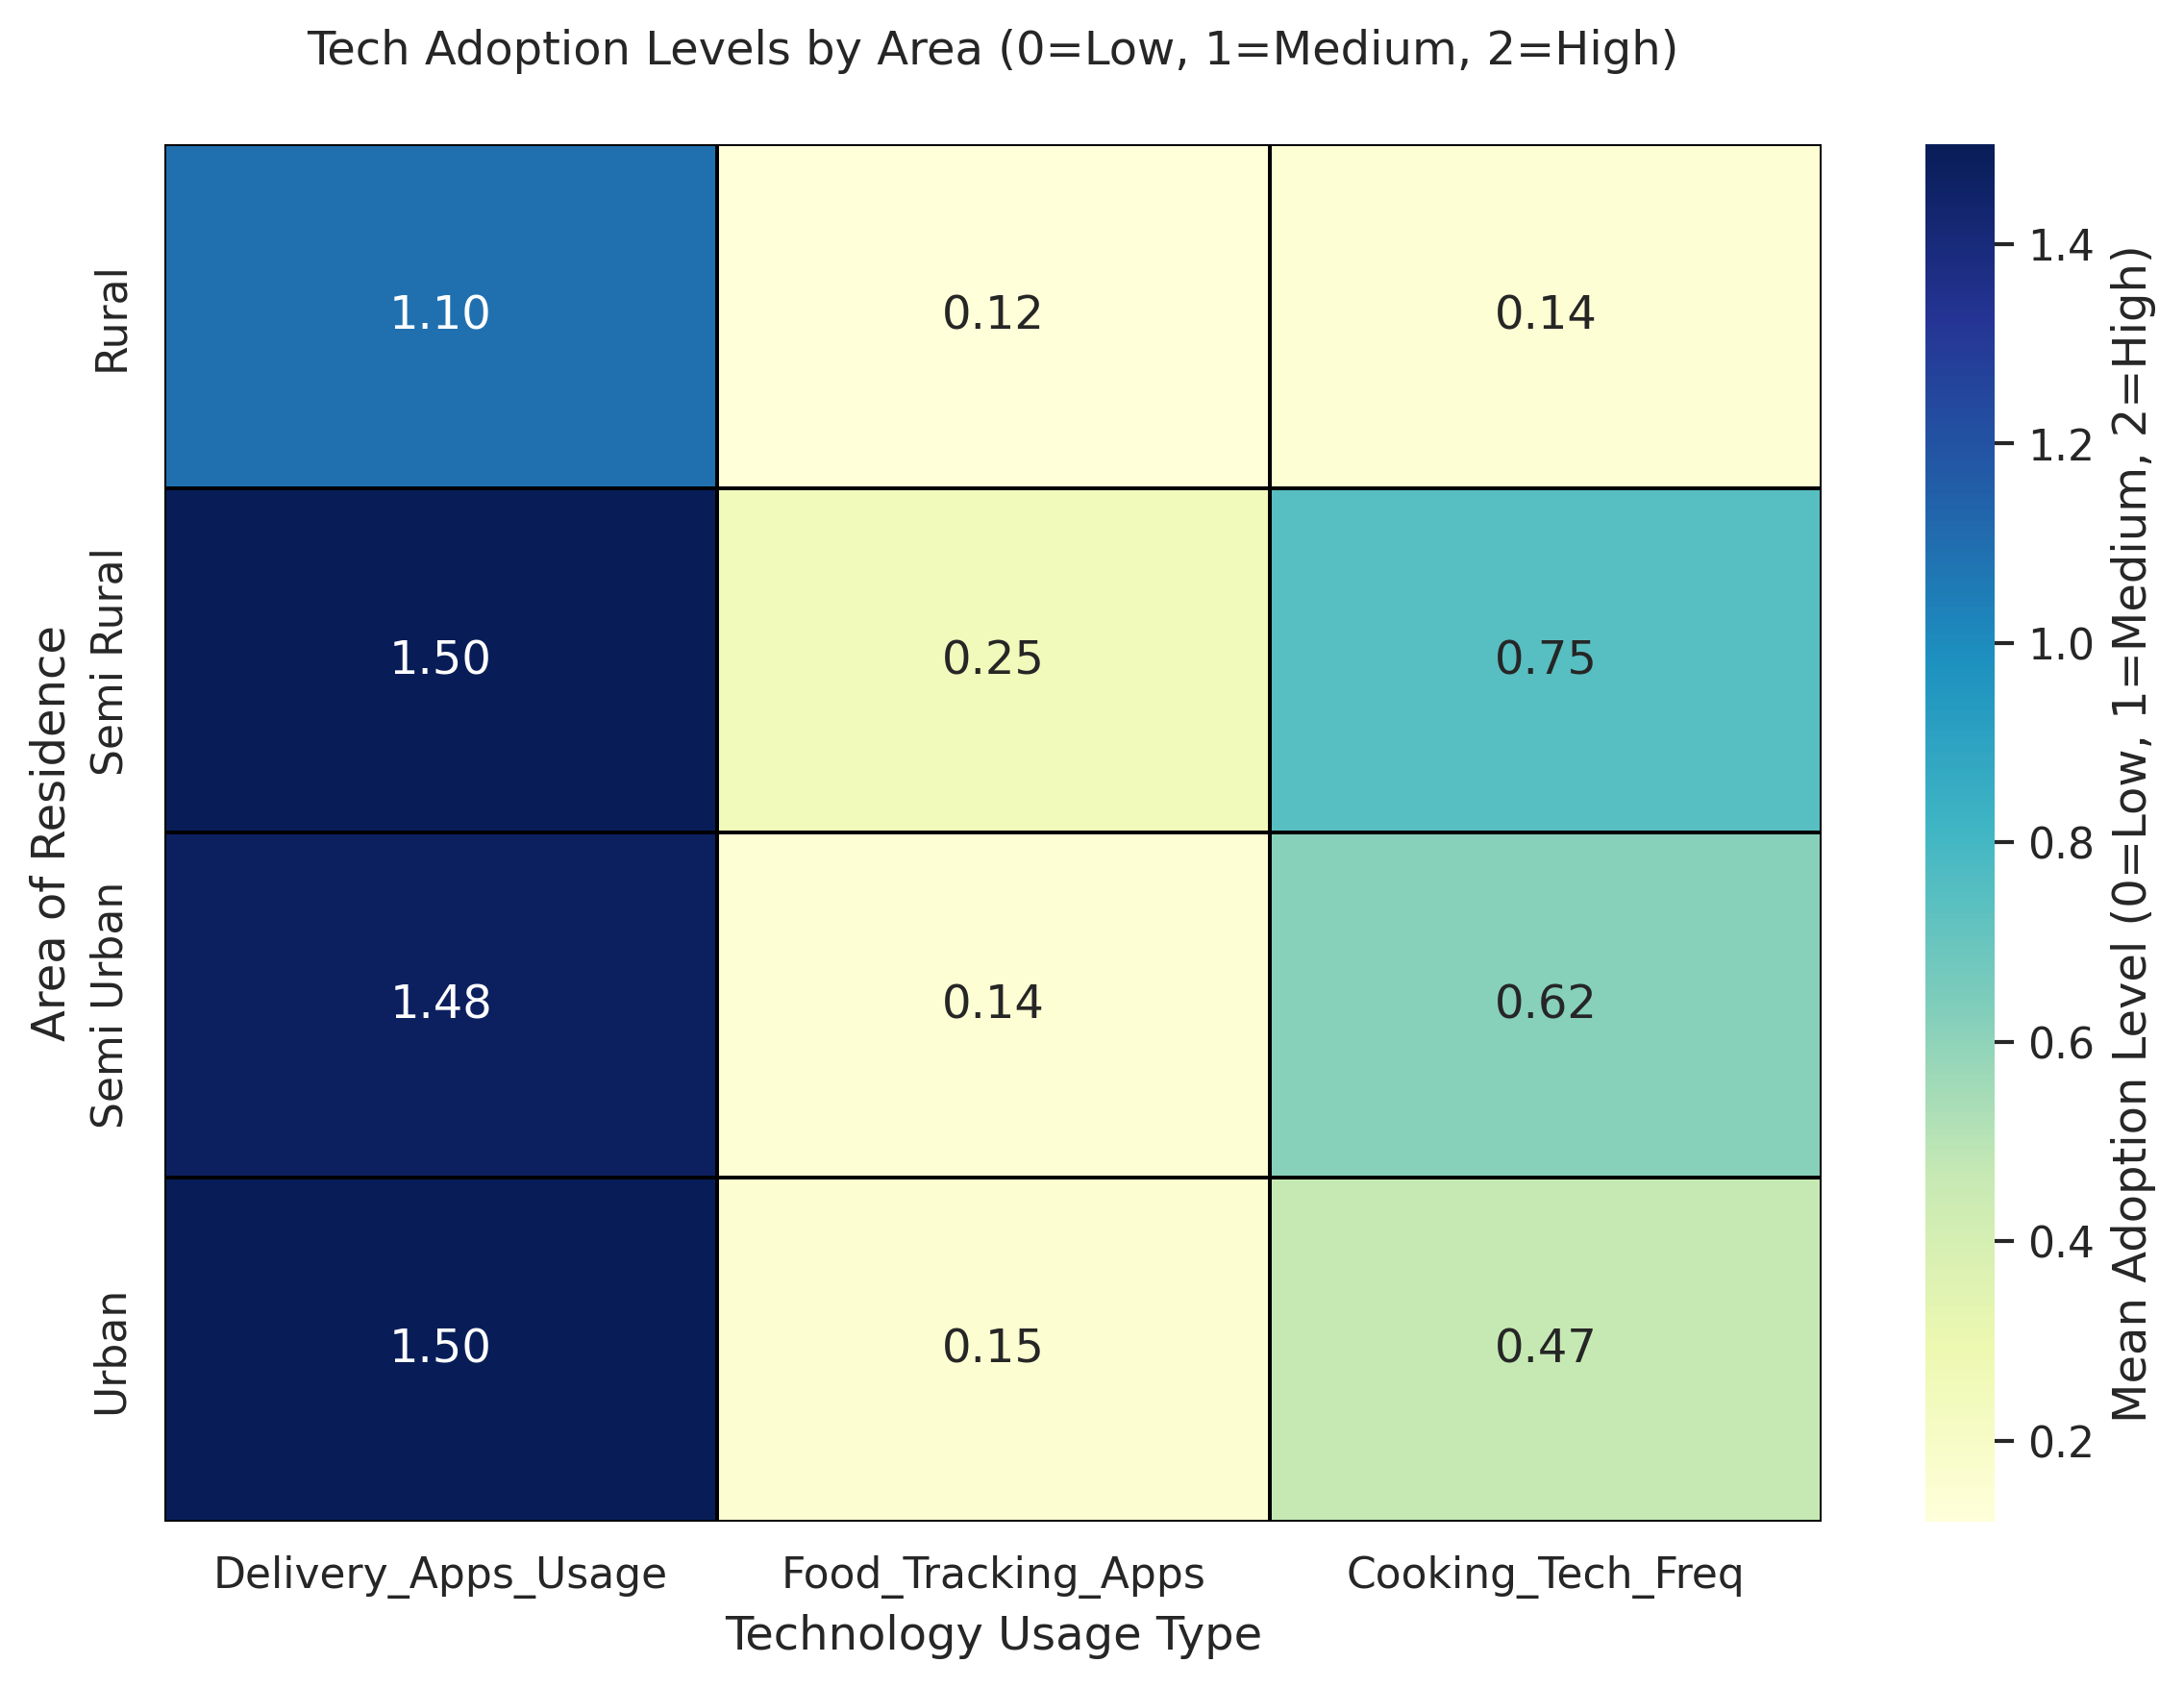

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Ensure 'Semi Rural' is mapped to 'Semi Urban' for consistent categories
# df['Area'] = df['Area'].replace({'Semi Rural': 'Semi Urban'})

sns.set_theme(style="white", context="paper", font_scale=1.2)

# Define tech adoption columns
tech_cols = ['Delivery_Apps_Usage', 'Food_Tracking_Apps', 'Cooking_Tech_Freq']

# Create a copy of the relevant DataFrame subset
tech_adoption_df = df[['Area'] + tech_cols].copy()

# Encode categorical tech usage to numerical (0=low, 1=medium, 2=high)
# Mapping logic from previous cells:
# 0: no/never
# 1: sometimes/occasionally
# 2: yes/always/often/frequently
def map_tech_usage(x):
    x = str(x).lower()
    if any(w in x for w in ['always', 'frequently', 'often', 'yes']):
        return 2
    elif any(w in x for w in ['sometimes', 'occasionally']):
        return 1
    else:
        return 0

for col in tech_cols:
    tech_adoption_df[col] = tech_adoption_df[col].apply(map_tech_usage)

# Calculate the mean tech adoption for each area
mean_tech_adoption = tech_adoption_df.groupby('Area')[tech_cols].mean()

# Generate the heatmap
plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(mean_tech_adoption, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, linecolor='black', cbar_kws={'label': 'Mean Adoption Level (0=Low, 1=Medium, 2=High)'})
plt.title('Tech Adoption Levels by Area (0=Low, 1=Medium, 2=High)', pad=20)
plt.xlabel('Technology Usage Type')
plt.ylabel('Area of Residence')
plt.tight_layout()
plt.savefig('Adv_TechAdoption_Heatmap_HQ.png')
plt.show()


In [ ]:
# Fix lengths and try again
valid_df = df.dropna(subset=['Skip_Num', 'Local_Food_Num'])
tau, p_tau = kendalltau(valid_df['Skip_Num'], valid_df['Local_Food_Num'])
print(f"Kendall Tau for Skip Meals vs Local Food Freq: {tau:.3f}, p-value: {p_tau:.4e}")
import os
print([f for f in os.listdir('.') if f.startswith('Adv')])

Kendall Tau for Skip Meals vs Local Food Freq: 0.079, p-value: 2.6615e-02
['Adv_ParallelCoords_HQ.png', 'Adv2_Hexbin_HQ.png', 'Adv_Ridgeline_HQ.png', 'Adv_Correlogram_HQ.png', 'Adv2_FacetKDE_HQ.png', 'Adv2_AndrewsCurves_HQ.png', 'Adv_SwarmBox_HQ.png', 'Adv_Clustermap_HQ.png', 'Adv2_Correlogram_HQ.png', 'Adv_2DKDE_HQ.png', 'Adv2_SplitViolin_HQ.png', 'Adv_Pairplot_HQ.png']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pandas.plotting import radviz
import networkx as nx
from statsmodels.graphics.mosaicplot import mosaic
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Preprocessing for deeper insights
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
freq_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(freq_map).fillna(0)
df['Local_Food_Num'] = df['Local_Food_Freq'].map(freq_map).fillna(0)
df['Processed_Food_Num'] = df['Processed_Food_Freq'].map(freq_map).fillna(0)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))
df['Travel_Time_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float).fillna(15) # Default imputation

sns.set_theme(style="white", context="paper", font_scale=1.2)

# 1. PCA Biplot (Principal Component Analysis)
features = ['Age_Num', 'Affordability_Num', 'Skip_Num', 'Local_Food_Num', 'Processed_Food_Num', 'Travel_Time_Num']
x_pca = df[features].dropna()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_pca)
pca = PCA(n_components=2)
pcs = pca.fit_transform(x_scaled)
df_pca = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
df_pca['Area'] = df.loc[x_pca.index, 'Area'].values

plt.figure(figsize=(10, 8), dpi=300)
sns.scatterplot(x='PC1', y='PC2', hue='Area', data=df_pca, alpha=0.6, palette='Set1', s=60)

# Draw factor loadings (arrows)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0]*2.5, loadings[i, 1]*2.5, color='black', alpha=0.8, head_width=0.05)
    plt.text(loadings[i, 0]*2.7, loadings[i, 1]*2.7, feature, color='black', ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Advanced Figure 6: PCA Biplot of Multivariate Dietary & Demographic Features', pad=20)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('Adv3_PCABiplot_HQ.png')
plt.close()

# 2. RadViz Projection
plt.figure(figsize=(10, 8), dpi=300)
rad_features = ['Age_Num', 'Affordability_Num', 'Skip_Num', 'Travel_Time_Num', 'Local_Food_Num', 'Area']
rad_df = df[rad_features].dropna()
# Max-Min Normalization for RadViz
for col in rad_features[:-1]:
    rad_df[col] = (rad_df[col] - rad_df[col].min()) / (rad_df[col].max() - rad_df[col].min())

radviz(rad_df, 'Area', colormap=plt.get_cmap('Set2'), alpha=0.6)
plt.title('Advanced Figure 7: RadViz Non-Linear Projection of Food Insecurity Markers', pad=20)
plt.tight_layout()
plt.savefig('Adv3_RadViz_HQ.png')
plt.close()

# 3. Mosaic Plot (Multi-categorical marginalization intersection)
plt.figure(figsize=(12, 8), dpi=300)
# Clean columns for display
df['Food_Insec_Bin'] = df['Food_Insecurity'].apply(lambda x: 'Insecure' if str(x).strip().lower()=='yes' else 'Secure')
df['Discrim'] = df['Discrimination_Exp'].apply(lambda x: 'Discrim: Yes' if str(x).strip().lower()=='yes' else 'Discrim: No')

mosaic_df = df[['Area', 'Food_Insec_Bin', 'Discrim']].dropna()
mosaic(mosaic_df, ['Area', 'Food_Insec_Bin', 'Discrim'], title='Advanced Figure 8: Mosaic Plot of Marginalization Intersections',
       gap=0.015, labelizer=lambda k: '')
plt.tight_layout()
plt.savefig('Adv3_Mosaic_HQ.png')
plt.close()

# 4. Correlation Network Graph (Topology of Variables)
plt.figure(figsize=(10, 10), dpi=300)
corr_matrix = x_pca.corr(method='spearman')
G = nx.Graph()

for col in corr_matrix.columns:
    G.add_node(col)

# Add edges based on correlation threshold
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        weight = corr_matrix.iloc[i, j]
        if abs(weight) > 0.15:  # Cut-off to only show meaningful relationships
            G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j], weight=weight)

pos = nx.spring_layout(G, seed=42, k=0.9)
edges = G.edges()
weights = [abs(G[u][v]['weight']) * 8 for u,v in edges]
colors = ['teal' if G[u][v]['weight'] > 0 else 'crimson' for u,v in edges]

nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='whitesmoke', edgecolors='black')
nx.draw_networkx_edges(G, pos, width=weights, edge_color=colors, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight='bold')

plt.title('Advanced Figure 9: Network Topology of Feature Correlations\n(Teal = Positive, Crimson = Negative)', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('Adv3_Network_HQ.png')
plt.close()

<Figure size 3600x2400 with 0 Axes>

<Figure size 6000x3000 with 0 Axes>

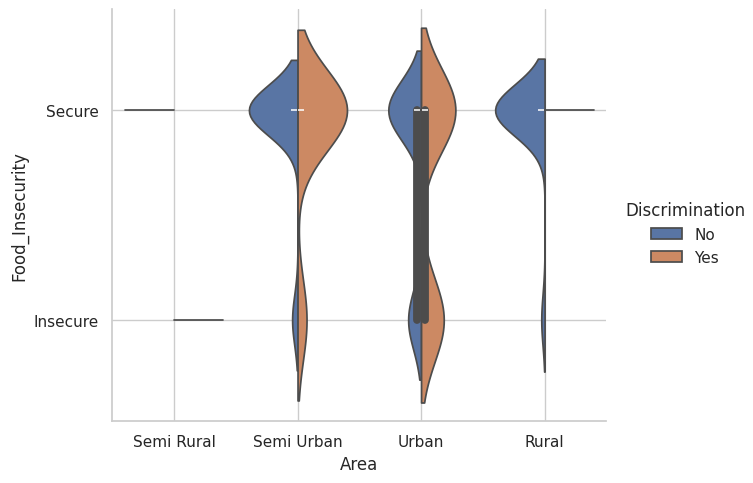

In [ ]:
plt.figure(figsize=(20, 10), dpi=300)
mosaic_df.rename(columns={"Discrim": "Discrimination", 'Food_Insec_Bin':'Food_Insecurity'}, inplace=True)
sns.set_theme(style="whitegrid")
g= sns.catplot(data=mosaic_df, x="Area", y="Food_Insecurity", hue="Discrimination", kind='violin',split='true')
g._legend.set_bbox_to_anchor((1.2, 0.5))
g._legend.set_loc("right")
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import PathPatch
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')
import math

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Prep
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
freq_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(freq_map).fillna(0)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))
df['Travel_Time_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float).fillna(15)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Raincloud Plot (DIY using matplotlib & seaborn)
# Visualizing precise distribution of Affordability across Areas
plt.figure(figsize=(12, 7), dpi=300)
areas = df['Area'].unique()
colors = sns.color_palette('Set2', len(areas))

for i, area in enumerate(areas):
    data = df[df['Area'] == area]['Affordability_Num'].dropna()
    # Half violin
    v = plt.violinplot(data, positions=[i], showmeans=False, showextrema=False, showmedians=False)
    for b in v['bodies']:
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], i, np.inf)
        b.set_color(colors[i])
        b.set_alpha(0.5)

    # Strip plot
    y_jitter = data
    x_jitter = np.random.normal(i - 0.15, 0.04, size=len(data))
    plt.scatter(x_jitter, y_jitter, s=15, color=colors[i], alpha=0.6, edgecolors='white', linewidths=0.5)

    # Boxplot
    plt.boxplot(data, positions=[i], widths=0.1, showfliers=False,
                boxprops=dict(facecolor='white', color='black', linewidth=1.2),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.2),
                capprops=dict(color='black', linewidth=1.2), patch_artist=True)

plt.xticks(range(len(areas)), areas)
plt.title('Advanced Figure 10: Raincloud Plot of Affordability Ratings by Area', pad=15)
plt.ylabel('Affordability Rating (1-5)')
plt.tight_layout()
plt.savefig('Adv4_Raincloud_HQ.png')
plt.close()


# 2. Polar/Spider Plot of Sustainability & Advocacy Variables (Obj 7 & 8)
# Map categories to numeric (0-1)
sus_cols = ['Env_Impact_Consideration', 'Willing_Pay_Premium_Env', 'Eco_Packaging_Importance', 'Policy_Awareness', 'Advocacy_Participation']
sus_df = df[['Area'] + sus_cols].copy()

def map_sus(val):
    val = str(val).lower()
    if any(w in val for w in ['always', 'very', 'important', 'yes']): return 1.0
    if any(w in val for w in ['sometimes', 'moderately', 'occasionally', 'neutral']): return 0.5
    return 0.0

for col in sus_cols:
    sus_df[col] = sus_df[col].apply(map_sus)

radar_data = sus_df.groupby('Area').mean().reset_index()
categories = ['Env. Impact', 'Willing to Pay Premium', 'Eco Packaging', 'Policy Awareness', 'Advocacy Part.']
N = len(categories)

angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), dpi=300, subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=11)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=8)
plt.ylim(0, 1)

for i, row in radar_data.iterrows():
    values = row.drop('Area').values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Area'])
    ax.fill(angles, values, alpha=0.15)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Advanced Figure 11: Sustainability & Advocacy Footprint by Area', y=1.08)
plt.tight_layout()
plt.savefig('Adv4_Polar_HQ.png')
plt.close()


# 3. Categorical Bubble Heatmap (Income vs Area for Meal Skipping)
plt.figure(figsize=(10, 7), dpi=300)
bubble_df = df.groupby(['Income', 'Area']).agg({'Skip_Num': 'mean', 'Affordability_Num': 'mean', 'Age_Num': 'count'}).reset_index()
# Rename count to 'Size'
bubble_df.rename(columns={'Age_Num': 'Count'}, inplace=True)

# Encode categorical axes
x_labels = bubble_df['Area'].unique()
y_labels = bubble_df['Income'].unique()
x_map = {l: i for i, l in enumerate(x_labels)}
y_map = {l: i for i, l in enumerate(y_labels)}

bubble_df['X'] = bubble_df['Area'].map(x_map)
bubble_df['Y'] = bubble_df['Income'].map(y_map)

scatter = plt.scatter(bubble_df['X'], bubble_df['Y'],
                      s=bubble_df['Skip_Num']*300 + 50, # Size = Skip Meals
                      c=bubble_df['Affordability_Num'], # Color = Affordability
                      cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidth=1)

plt.xticks(list(x_map.values()), list(x_map.keys()))
plt.yticks(list(y_map.values()), list(y_map.keys()))
cbar = plt.colorbar(scatter)
cbar.set_label('Mean Affordability (Red=Low, Green=High)')

# Legend for size
for skip_val in [1, 2, 3]:
    plt.scatter([], [], s=skip_val*300 + 50, c='gray', label=f'Skip Frequency {skip_val}')
plt.legend(title="Mean Skip Frequency", bbox_to_anchor=(1.3, 0.5), loc='center left', frameon=False)

plt.title('Advanced Figure 12: Categorical Bubble Matrix\nSize = Meal Skipping Freq | Color = Affordability', pad=20)
plt.tight_layout()
plt.savefig('Adv4_BubbleMatrix_HQ.png')
plt.close()


# 4. 3D Scatter Plot (Age vs Travel Time vs Affordability, sized by Skip Meals)
fig = plt.figure(figsize=(10, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')

area_colors = {'Urban': 'blue', 'Semi Urban': 'green', 'Rural': 'red'}
df_3d = df.dropna(subset=['Age_Num', 'Travel_Time_Num', 'Affordability_Num', 'Skip_Num', 'Area'])

for area in df_3d['Area'].unique():
    subset = df_3d[df_3d['Area'] == area]
    ax.scatter(subset['Age_Num'], subset['Travel_Time_Num'], subset['Affordability_Num'],
               c=area_colors[area], s=(subset['Skip_Num']+1)*20, label=area, alpha=0.6, edgecolors='w')

ax.set_xlabel('Age')
ax.set_ylabel('Travel Time (Mins)')
ax.set_zlabel('Affordability Rating')
ax.set_title('Advanced Figure 13: 3D Scatter of Demographics, Travel & Affordability\n(Bubble Size = Meal Skipping)', pad=20)
ax.legend(title="Area")
plt.savefig('Adv4_3DScatter_HQ.png')
plt.close()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Prep
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
freq_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(freq_map).fillna(0)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))
df['Travel_Time_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float).fillna(15)

# 4. 3D Scatter Plot (Age vs Travel Time vs Affordability, sized by Skip Meals)
fig = plt.figure(figsize=(10, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# dynamically map colors
area_colors = dict(zip(df['Area'].dropna().unique(), sns.color_palette("Set1", len(df['Area'].dropna().unique()))))
df_3d = df.dropna(subset=['Age_Num', 'Travel_Time_Num', 'Affordability_Num', 'Skip_Num', 'Area'])

for area in df_3d['Area'].unique():
    subset = df_3d[df_3d['Area'] == area]
    ax.scatter(subset['Age_Num'], subset['Travel_Time_Num'], subset['Affordability_Num'],
               c=[area_colors[area]], s=(subset['Skip_Num']+1)*30, label=area, alpha=0.6, edgecolors='w')

ax.set_xlabel('Age')
ax.set_ylabel('Travel Time (Mins)')
ax.set_zlabel('Affordability Rating')
ax.set_title('Advanced Figure 13: 3D Scatter of Demographics, Travel & Affordability\n(Bubble Size = Meal Skipping)', pad=20)
ax.legend(title="Area", bbox_to_anchor=(1.2, 0.5), loc='center')
plt.tight_layout()
plt.savefig('Adv4_3DScatter_HQ.png')
plt.close()

import os
print([f for f in os.listdir('.') if f.startswith('Adv4_')])

['Adv4_Raincloud_HQ.png', 'Adv4_Polar_HQ.png', 'Adv4_3DScatter_HQ.png', 'Adv4_BubbleMatrix_HQ.png']


KeyError: 'Rural'

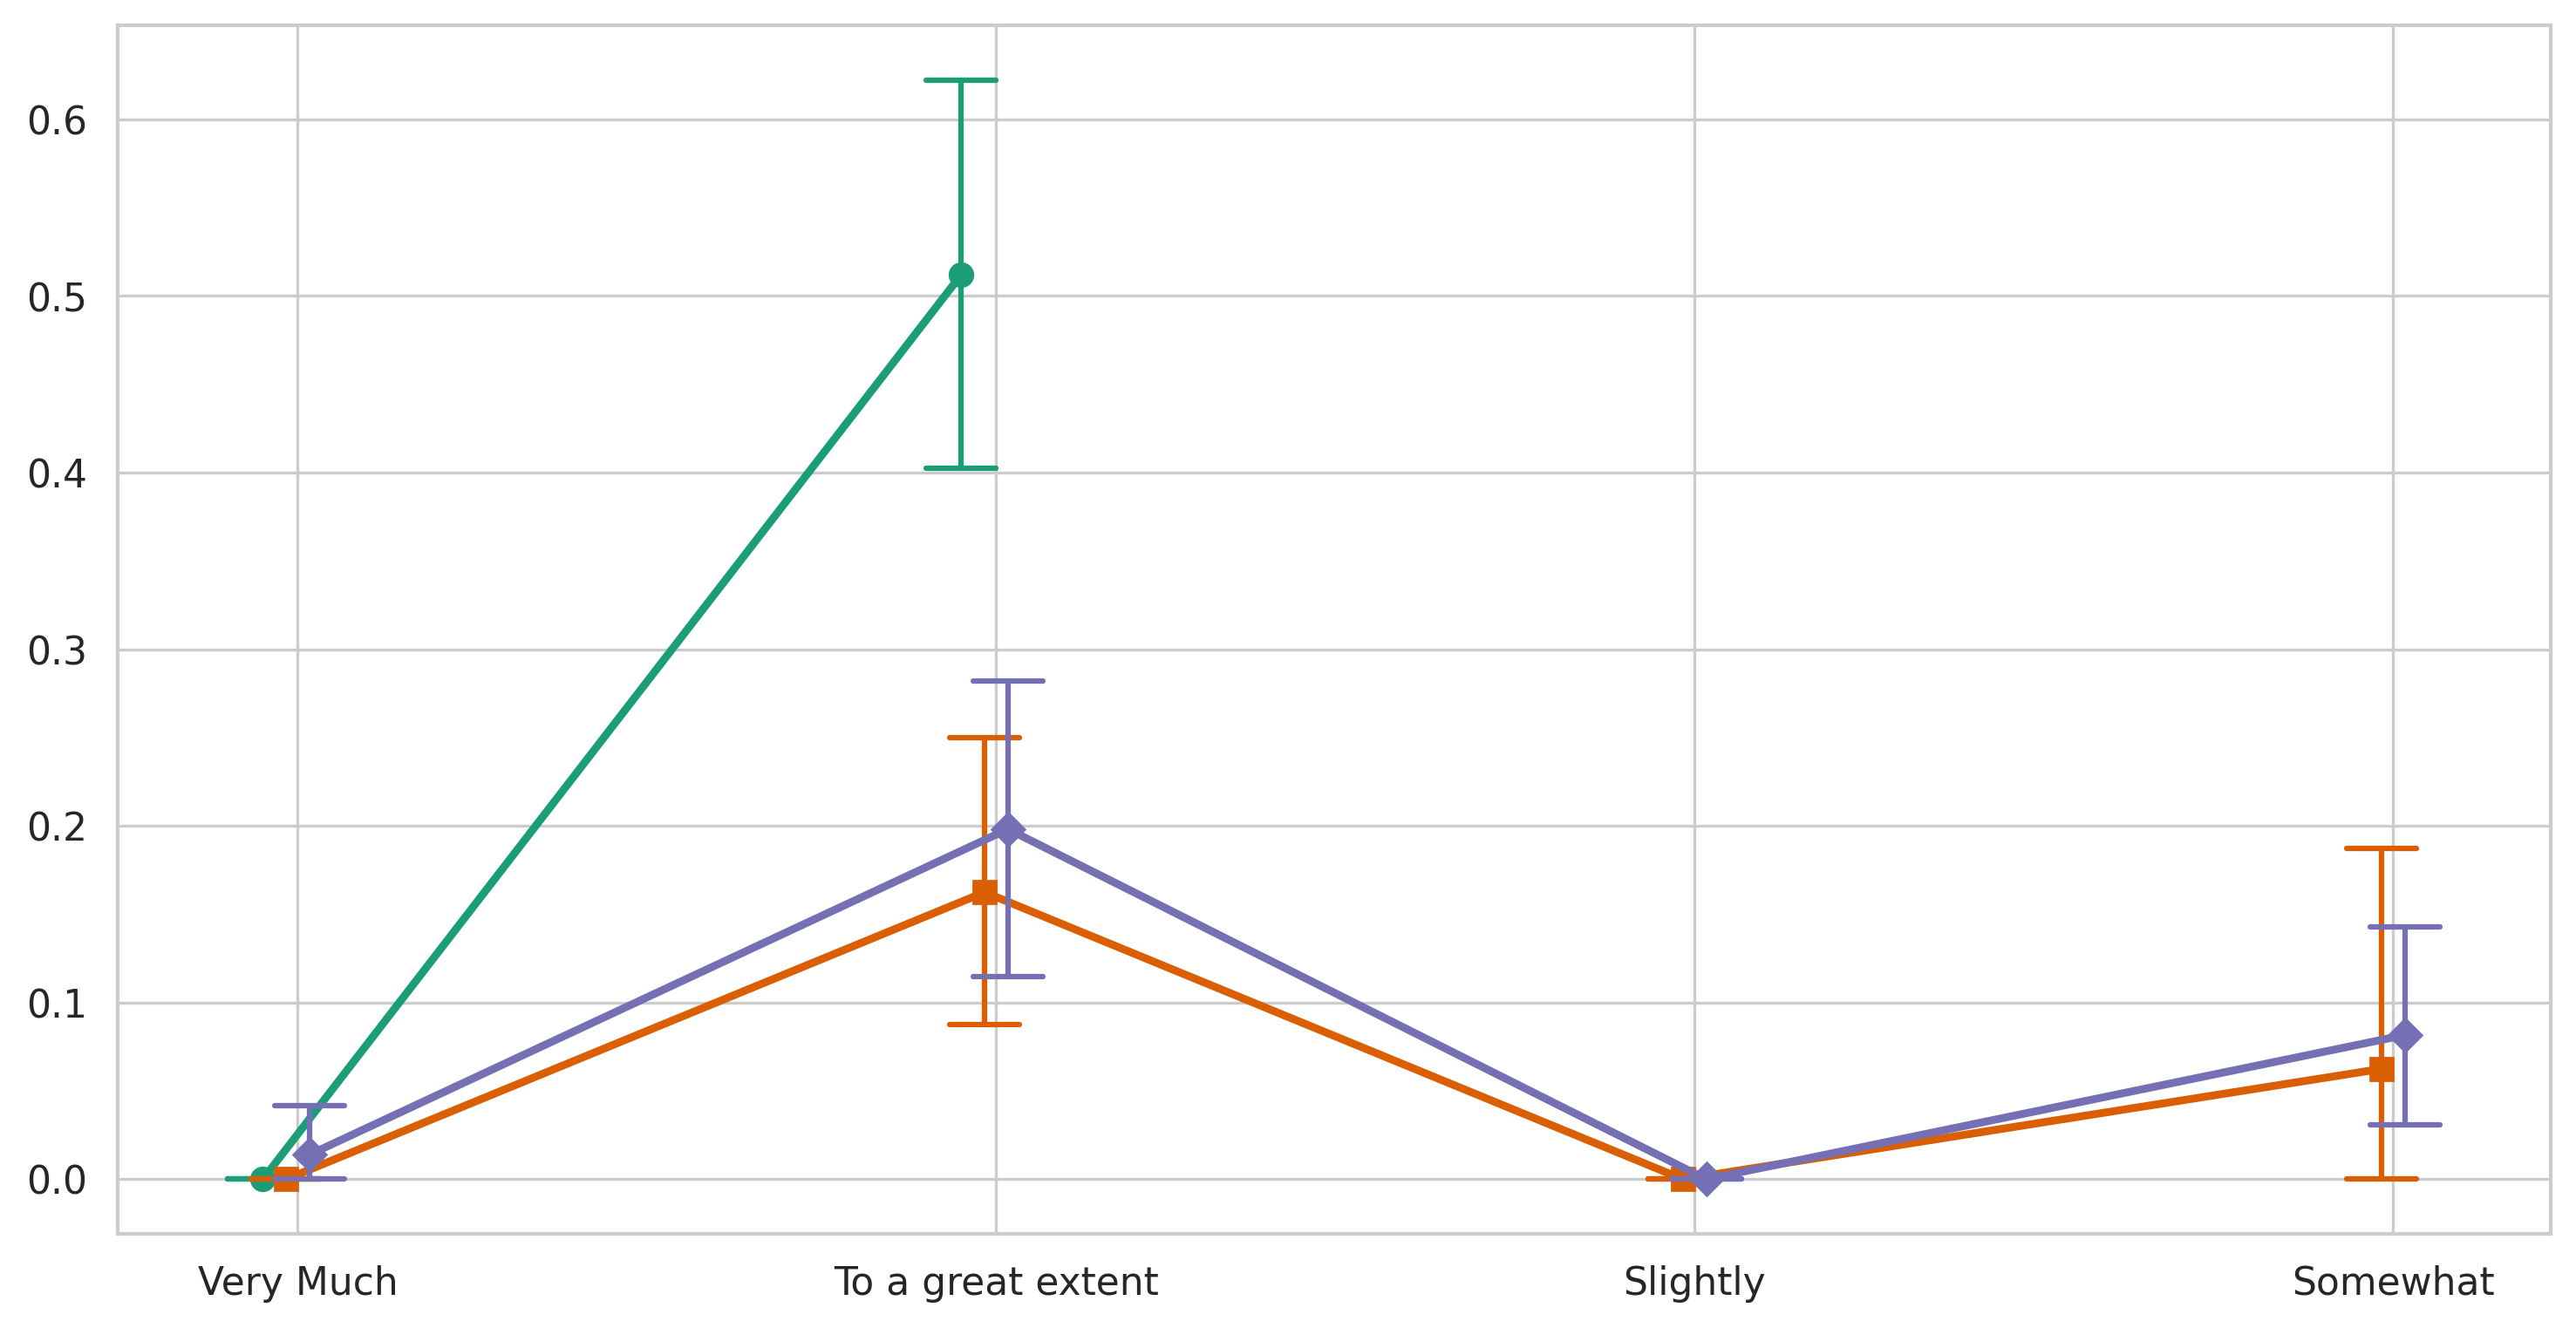

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
import math
warnings.filterwarnings('ignore')

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Prep
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)
freq_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}
df['Skip_Num'] = df['Skip_Meals_Freq'].map(freq_map).fillna(0)
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))
df['Travel_Time_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float).fillna(15)
df['Local_Food_Num'] = df['Local_Food_Freq'].map(freq_map).fillna(0)
df['Processed_Food_Num'] = df['Processed_Food_Freq'].map(freq_map).fillna(0)
df['Fast_Food_Num'] = df['Fast_Food_Freq'].map(freq_map).fillna(0)

# Set global aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# =========================================================================
# 1. K-Means Clustering + T-SNE Projection (Cluster Analysis)
# =========================================================================
cluster_features = ['Age_Num', 'Affordability_Num', 'Skip_Num', 'Travel_Time_Num', 'Local_Food_Num', 'Processed_Food_Num', 'Fast_Food_Num']
df_cluster = df.dropna(subset=cluster_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

# KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)
df_cluster['Cluster_Label'] = df_cluster['Cluster'].map({0: 'Archetype A', 1: 'Archetype B', 2: 'Archetype C'})

# TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df_cluster['TSNE1'] = X_tsne[:, 0]
df_cluster['TSNE2'] = X_tsne[:, 1]

plt.figure(figsize=(10, 8), dpi=300)
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster_Label', style='Area', data=df_cluster,
                palette='Set1', s=80, alpha=0.7)
plt.title('Advanced Figure 14: T-SNE Projection of Behavioral Dietary Archetypes (K-Means)', pad=15)
plt.xlabel('T-SNE Dimension 1')
plt.ylabel('T-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Adv5_TSNE_Clusters_HQ.png')
plt.close()


# =========================================================================
# 2. Cluster Profiling Radar Chart (Cluster Analysis)
# =========================================================================
radar_df = df_cluster.groupby('Cluster_Label')[cluster_features].mean().reset_index()
# Normalize for radar chart
for col in cluster_features:
    radar_df[col] = radar_df[col] / radar_df[col].max()

categories = ['Age', 'Affordability', 'Skip Meals', 'Travel Time', 'Local Food', 'Processed', 'Fast Food']
N = len(categories)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), dpi=300, subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=10)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.5, 0.8], ["Low", "Medium", "High"], color="grey", size=8)
plt.ylim(0, 1)

colors_radar = sns.color_palette("Set1", 3)
for i, row in radar_df.iterrows():
    values = row.drop('Cluster_Label').values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Cluster_Label'], color=colors_radar[i])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Advanced Figure 15: K-Means Cluster Centroids Footprint Profile', y=1.08)
plt.tight_layout()
plt.savefig('Adv5_Cluster_Radar_HQ.png')
plt.close()


# =========================================================================
# 3. Asymmetric Cross-Correlation Heatmap (Correlation Analysis)
# =========================================================================
# Correlate Demographics vs Dietary Habits
demographics = ['Age_Num', 'Affordability_Num', 'Travel_Time_Num']
diets = ['Skip_Num', 'Local_Food_Num', 'Processed_Food_Num', 'Fast_Food_Num']

cross_corr = pd.DataFrame(index=demographics, columns=diets)
for d in demographics:
    for f in diets:
        # Use spearman for ordinal vs continuous robustness
        corr = df_cluster[[d, f]].corr(method='spearman').iloc[0, 1]
        cross_corr.loc[d, f] = corr

cross_corr = cross_corr.astype(float)

plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(cross_corr, annot=True, cmap='vlag', center=0, vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title('Advanced Figure 16: Cross-Correlation Heatmap\n(Demographics/Access vs. Dietary Habits)', pad=15)
plt.ylabel('Access & Demographics')
plt.xlabel('Dietary & Insecurity Behaviors')
plt.tight_layout()
plt.savefig('Adv5_CrossCorr_HQ.png')
plt.close()


# =========================================================================
# 4. Comparative Dumbbell Plot (Comparative Analysis)
# =========================================================================
# Compare Affordability between Male and Female across Income Brackets
dumb_df = df.groupby(['Income', 'Gender'])['Affordability_Num'].mean().unstack().dropna()
# Only keep Male and Female for standard comparison
dumb_df = dumb_df[['Female', 'Male']]

# Sort by Male affordability for visual staircase
dumb_df = dumb_df.sort_values(by='Male')

plt.figure(figsize=(10, 6), dpi=300)
# Draw lines
for i, income in enumerate(dumb_df.index):
    f_val = dumb_df.loc[income, 'Female']
    m_val = dumb_df.loc[income, 'Male']
    plt.plot([f_val, m_val], [i, i], color='gray', alpha=0.5, zorder=1)

# Draw points
plt.scatter(dumb_df['Female'], range(len(dumb_df)), color='salmon', s=100, label='Female', zorder=2)
plt.scatter(dumb_df['Male'], range(len(dumb_df)), color='royalblue', s=100, label='Male', zorder=2)

plt.yticks(range(len(dumb_df)), dumb_df.index)
plt.title('Advanced Figure 17: Dumbbell Plot Comparing Mean Affordability\nBetween Genders Across Income Brackets', pad=15)
plt.xlabel('Mean Affordability Rating (1-5)')
plt.ylabel('Annual Income')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('Adv5_Dumbbell_HQ.png')
plt.close()

# =========================================================================
# 5. Grouped Pointplot with Confidence Intervals (Comparative Analysis)
# =========================================================================
plt.figure(figsize=(12, 6), dpi=300)
sns.pointplot(data=df, x='Cultural_Influence', y='Skip_Num', hue='Area',
              dodge=True, markers=['o', 's', 'D'], capsize=.1, errwidth=1.5, palette='Dark2')
plt.title('Advanced Figure 18: Comparative Pointplot with 95% Confidence Intervals\nMeal Skipping across Cultural Influence and Area', pad=15)
plt.ylabel('Mean Meal Skipping Frequency (0-4)')
plt.xlabel('Self-Reported Level of Cultural Influence on Food')
plt.xticks(rotation=45)
plt.legend(title='Area', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Adv5_Pointplot_CI_HQ.png')
plt.close()

import os
print([f for f in os.listdir('.') if f.startswith('Adv5_')])

In [ ]:
# Fixing pointplot markers error
plt.figure(figsize=(12, 6), dpi=300)
# Ensure there are enough markers for each area category (Urban, Semi Urban, Rural -> 3 markers needed)
sns.pointplot(data=df, x='Cultural_Influence', y='Skip_Num', hue='Area',
              dodge=True, markers=['o', 's', '^', 'D', 'v', 'x'][:len(df['Area'].dropna().unique())],
              capsize=.1, palette='Dark2')
plt.title('Advanced Figure 18: Comparative Pointplot with 95% Confidence Intervals\nMeal Skipping across Cultural Influence and Area', pad=15)
plt.ylabel('Mean Meal Skipping Frequency (0-4)')
plt.xlabel('Self-Reported Level of Cultural Influence on Food')
plt.xticks(rotation=45)
plt.legend(title='Area', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Adv5_Pointplot_CI_HQ.png')
plt.close()

import os
print([f for f in os.listdir('.') if f.startswith('Adv5_')])

['Adv5_CrossCorr_HQ.png', 'Adv5_Cluster_Radar_HQ.png', 'Adv5_Dumbbell_HQ.png', 'Adv5_TSNE_Clusters_HQ.png', 'Adv5_Pointplot_CI_HQ.png']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# Preprocessing for Objective 4
df['Skip_Num'] = df['Skip_Meals_Freq'].map({'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}).fillna(0)

# Clean Stigma Awareness
df['Stigma_Clean'] = df['Stigma_Awareness'].apply(lambda x: 'Yes' if str(x).strip().lower()=='yes' else 'No')

# Clean Emotional Eating
def clean_emotional(val):
    val = str(val).lower()
    if 'yes' in val: return 'Used Food to Cope'
    if 'sometimes' in val or 'occasionally' in val: return 'Sometimes Coped'
    return 'Never Coped'
df['Emotional_Eating_Clean'] = df['Emotional_Eating_Exp'].apply(clean_emotional)

# Clean Stress Appetite Change
def clean_appetite(val):
    val = str(val).lower()
    if any(w in val for w in ['often', 'always', 'frequently', 'yes']): return 'Appetite Changed Often'
    if any(w in val for w in ['sometimes', 'occasionally']): return 'Appetite Changed Sometimes'
    return 'Appetite Unchanged'
df['Stress_Appetite_Clean'] = df['Stress_Appetite_Change'].apply(clean_appetite)

# 1. Flow Diagram (Alternative to Sankey using Stacked Bar Pipeline)
# Food Insec -> Emotional Eating -> Appetite Change
plt.figure(figsize=(12, 6), dpi=300)
# Create a pivot table to show the flow
flow_df = df.groupby(['Food_Insecurity', 'Emotional_Eating_Clean']).size().unstack(fill_value=0)
# Normalize to percentages
flow_df_pct = flow_df.div(flow_df.sum(axis=1), axis=0) * 100

flow_df_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 6), width=0.6)
plt.title('Objective 4 (Fig 29): Progression from Food Insecurity to Emotional Eating (Pipeline)', pad=15)
plt.ylabel('Percentage within Insecurity Group (%)')
plt.xlabel('Experienced Food Insecurity in Past Year')
plt.legend(title='Emotional Eating / Coping', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Obj4_FlowBar_HQ.png')
plt.close()

# 2. Stacked 100% Bar Chart (Stigma vs Area and Gender)
plt.figure(figsize=(12, 7), dpi=300)
# Create cross-tabulation
stigma_crosstab = pd.crosstab([df['Area'], df['Gender']], df['Stigma_Clean'], normalize='index') * 100
stigma_crosstab.plot(kind='barh', stacked=True, color=['#ff9999','#66b3ff'], figsize=(10, 8), edgecolor='white')
plt.title('Objective 4 (Fig 30): Stigma Awareness Regarding Food/Mental Health by Demographics', pad=15)
plt.xlabel('Percentage of Population (%)')
plt.ylabel('Area & Gender Intersection')
plt.legend(title='Believes Stigma Exists', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Obj4_Stigma_100Bar_HQ.png')
plt.close()

# 3. Violin Plot (Physiological/Psychological Feedback Loop)
plt.figure(figsize=(10, 6), dpi=300)
# Filter strictly Yes or No for Food_Insecurity to make it clean
clean_insec_df = df[df['Food_Insecurity'].isin(['Yes', 'No'])]
sns.violinplot(data=clean_insec_df, x='Emotional_Eating_Clean', y='Skip_Num',
               hue='Food_Insecurity', split=True, inner="quart", palette='muted')
plt.title('Objective 4 (Fig 31): Physiological & Psychological Feedback Loop\n(Meal Skipping vs Emotional Coping)', pad=15)
plt.xlabel('Usage of Food as a Coping Mechanism')
plt.ylabel('Meal Skipping Frequency (0-4)')
plt.legend(title='Food Insecurity Experience', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Obj4_Violin_Feedback_HQ.png')
plt.close()

import os
print([f for f in os.listdir('.') if f.startswith('Obj4_')])

['Obj4_Violin_Feedback_HQ.png', 'Obj4_Stigma_100Bar_HQ.png', 'Obj4_FlowBar_HQ.png']


<Figure size 3600x1800 with 0 Axes>

<Figure size 3600x2100 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('Balanced_Gastronomy_Dataset.csv')

# 2. Create Affordability_Num
df['Affordability_Num'] = df['Affordability_Rating'].astype(str).str.extract(r'(\d+)').astype(float)

# 3. Create a dictionary freq_map
freq_map = {'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Often': 3, 'Always': 4}

# 4. Apply freq_map to frequency columns and fill NaNs with 0
df['Skip_Num'] = df['Skip_Meals_Freq'].map(freq_map).fillna(0)
df['Local_Food_Num'] = df['Local_Food_Freq'].map(freq_map).fillna(0)
df['Processed_Food_Num'] = df['Processed_Food_Freq'].map(freq_map).fillna(0)
df['Fast_Food_Num'] = df['Fast_Food_Freq'].map(freq_map).fillna(0)

# 5. Create Age_Num
df['Age_Num'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))

# 6. Create Travel_Time_Num and fill NaNs with 15
df['Travel_Time_Num'] = df['Travel_Time'].astype(str).str.extract(r'(\d+)').astype(float).fillna(15)

# 7. Create Income_Food_Alloc_Num
df['Income_Food_Alloc_Num'] = df['Income_Food_Allocation'].astype(str).str.extract(r'(\d+)').astype(float)

print("Data preparation complete. Displaying first 5 rows of the updated DataFrame:")
df.head()

Data preparation complete. Displaying first 5 rows of the updated DataFrame:


,Age,Gender,Area,Education,Income,Affordability_Rating,Distance_to_Market,Experienced_Shortages,Travel_Time,Income_Food_Allocation,...,Mental_Health_Food_Prog,Emotional_Eating_Exp,Affordability_Num,Skip_Num,Local_Food_Num,Processed_Food_Num,Fast_Food_Num,Age_Num,Travel_Time_Num,Income_Food_Alloc_Num
0,20,Female,Semi Rural,"High school graduate, diploma or the equivalent",Less than INR 1 Lakh,5 (Very Abundant),Less than 1km,No,Less than 15 minutes,10% - 20%,...,Strongly agree,Frequently,5.0,0.0,3.0,4.0,3.0,20,15.0,10.0
1,20,Female,Semi Rural,"High school graduate, diploma or the equivalent",Less than INR 1 Lakh,5 (Very Abundant),Less than 1km,No,Less than 15 minutes,10% - 20%,...,Strongly agree,Frequently,5.0,0.0,3.0,4.0,3.0,20,15.0,10.0
2,20,Female,Semi Rural,"High school graduate, diploma or the equivalent",Less than INR 1 Lakh,5 (Very Abundant),Less than 1km,No,Less than 15 minutes,10% - 20%,...,Strongly agree,Frequently,5.0,0.0,3.0,4.0,3.0,20,15.0,10.0
3,20,Female,Semi Rural,"High school graduate, diploma or the equivalent",Less than INR 1 Lakh,5 (Very Abundant),Less than 1km,No,Less than 15 minutes,10% - 20%,...,Strongly agree,Frequently,5.0,0.0,3.0,4.0,3.0,20,15.0,10.0
4,20,Female,Semi Rural,"High school graduate, diploma or the equivalent",Less than INR 1 Lakh,5 (Very Abundant),Less than 1km,No,Less than 15 minutes,10% - 20%,...,Strongly agree,Frequently,5.0,0.0,3.0,4.0,3.0,20,15.0,10.0


In [ ]:
from scipy.stats import spearmanr
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

# Define the numerical columns for p-value calculation
numerical_cols = [
    'Age_Num',
    'Affordability_Num',
    'Skip_Num',
    'Local_Food_Num',
    'Processed_Food_Num',
    'Fast_Food_Num',
    'Travel_Time_Num',
    'Income_Food_Alloc_Num'
]

# Create an empty DataFrame to store p-values
p_values_matrix = pd.DataFrame(np.nan, index=numerical_cols, columns=numerical_cols)

# Calculate p-values for each pair of columns
for col1 in numerical_cols:
    for col2 in numerical_cols:
        if col1 == col2:
            p_values_matrix.loc[col1, col2] = 0.0 # Correlation with itself is perfectly significant
        elif pd.isna(p_values_matrix.loc[col1, col2]): # Only calculate for unique pairs
            # Drop NaN values for the specific pair before calculating correlation
            temp_df = df[[col1, col2]].dropna()
            if len(temp_df) > 1: # Ensure there's enough data to calculate
                _, p_value = spearmanr(temp_df[col1], temp_df[col2])
                p_values_matrix.loc[col1, col2] = p_value
                p_values_matrix.loc[col2, col1] = p_value # Symmetrical matrix
            else:
                p_values_matrix.loc[col1, col2] = np.nan
                p_values_matrix.loc[col2, col1] = np.nan

print("Spearman Correlation P-value Matrix:")
p_values_matrix

Spearman Correlation P-value Matrix:


,Age_Num,Affordability_Num,Skip_Num,Local_Food_Num,Processed_Food_Num,Fast_Food_Num,Travel_Time_Num,Income_Food_Alloc_Num
Age_Num,0.000000e+00,1.691752e-14,1.557664e-01,3.935998e-07,9.300964e-01,8.053256e-01,8.881250e-09,7.441224e-01
Affordability_Num,1.691752e-14,0.000000e+00,7.803892e-08,1.564902e-41,1.424650e-03,1.216274e-05,9.040145e-01,2.165338e-19
Skip_Num,1.557664e-01,7.803892e-08,0.000000e+00,6.198678e-02,4.176936e-01,4.537051e-01,1.684922e-04,2.459950e-07
Local_Food_Num,3.935998e-07,1.564902e-41,6.198678e-02,0.000000e+00,2.228799e-07,1.052501e-11,3.035133e-01,2.820533e-03
Processed_Food_Num,9.300964e-01,1.424650e-03,4.176936e-01,2.228799e-07,0.000000e+00,7.611715e-22,1.274930e-03,4.480395e-11
Fast_Food_Num,8.053256e-01,1.216274e-05,4.537051e-01,1.052501e-11,7.611715e-22,0.000000e+00,6.134586e-12,1.295158e-01
Travel_Time_Num,8.881250e-09,9.040145e-01,1.684922e-04,3.035133e-01,1.274930e-03,6.134586e-12,0.000000e+00,1.497547e-03
Income_Food_Alloc_Num,7.441224e-01,2.165338e-19,2.459950e-07,2.820533e-03,4.480395e-11,1.295158e-01,1.497547e-03,0.000000e+00


In [ ]:
# Save the p_values_matrix DataFrame to a CSV file
p_values_matrix.to_csv('spearman_p_values_matrix.csv')
print("Spearman p-value matrix saved to 'spearman_p_values_matrix.csv'")

Spearman p-value matrix saved to 'spearman_p_values_matrix.csv'


In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from docx import Document

doc = Document('regression analysis food.docx')
tables = doc.tables
if tables:
    data = []
    for row in tables[0].rows:
        data.append([cell.text for cell in row.cells])
    df_table = pd.DataFrame(data[1:], columns=data[0])
    print(df_table.head(10))
    # Or just print all dependent variables
    print("\nUnique Dependent Variables:")
    print(df_table['Dependent Variable'].unique())
else:
    # Maybe it's not a docx table but a raw text in docx?
    for p in doc.paragraphs[:10]:
        print(p.text)

                                  Objective  \
0                Predicting Food Insecurity   
1                Predicting Food Insecurity   
2                Predicting Food Insecurity   
3                Predicting Food Insecurity   
4                Predicting Food Insecurity   
5                Predicting Food Insecurity   
6  Predicting Consumption of Processed Food   
7  Predicting Consumption of Processed Food   
8  Predicting Consumption of Processed Food   
9  Predicting Consumption of Processed Food   

                                  Dependent Variable Response Level  \
0  Have you experienced food insecurity in the pa...                  
1  Have you experienced food insecurity in the pa...                  
2  Have you experienced food insecurity in the pa...                  
3  Have you experienced food insecurity in the pa...                  
4  Have you experienced food insecurity in the pa...                  
5  Have you experienced food insecurity in the pa...    

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from docx import Document

# Load dataset
df = pd.read_csv('Gastronomy Research Questionnaire.csv') # Or the balanced one? Balanced is better for stats
df_bal = pd.read_csv('Balanced_Gastronomy_Dataset.csv')
df_bal.columns = ['Age', 'Gender', 'Area', 'Education', 'Income', 'Affordability_Rating', 'Distance_Market', 'Experienced_Shortages', 'Travel_Time', 'Income_Food_Allocation', 'Transport_Reliability', 'Local_Food_Freq', 'Local_Food_Factors', 'Processed_Food_Freq', 'Fast_Food_Freq', 'Dietary_Restrictions', 'Family_Meals_Freq', 'Food_Insecurity', 'Poor_Quality_Freq', 'Variety_Satisfaction', 'Malnutrition_Exp', 'Food_Aid_Reliance', 'Skip_Meals_Freq', 'Gov_Assistance_Exp', 'Community_Support_Food_Justice', 'Community_Event_Freq', 'Gov_Priority_Food_Justice', 'Policy_Awareness', 'Advocacy_Participation', 'Env_Impact_Consideration', 'Willing_Pay_Premium_Env', 'Grow_Own_Food_Freq', 'Eco_Packaging_Importance', 'Local_Ingred_Freq', 'Main_Food_Factor', 'Cultural_Influence', 'Cultural_Meal_Sharing', 'Expressing_Diet_Comfort', 'Preserve_Recipes_Imp', 'Comm_Celeb_Food_Cultures', 'Cooking_Skills_Imp', 'Discrimination_Exp', 'Lunchbox_Shaming_Exp', 'Anti_Shaming_Policy', 'Disability_Barrier', 'Language_Cultural_Barrier', 'Comm_Action_Awareness', 'Delivery_Apps_Usage', 'Blockchain_Comfort', 'Food_Tracking_Apps', 'Tech_Impact_Food', 'Food_Streaming_Freq', 'Cooking_Tech_Freq', 'Nutrition_Mental_Knowledge', 'Stigma_Awareness', 'Stress_Appetite_Change', 'Prof_Help_Food_Mental', 'Mental_Health_Food_Prog', 'Emotional_Eating_Exp']

# Define a mapping function to convert categorical to numeric for regression
def encode_data(data):
    d = data.copy()
    # Continuous / Ordinal Maps
    d['Age_Num'] = pd.to_numeric(d['Age'], errors='coerce').fillna(d['Age'].astype(str).str.extract(r'(\d+)')[0].astype(float))
    d['Gender_Num'] = d['Gender'].map({'Male': 0, 'Female': 1}) # Female=1

    # Area: Urban=2, Semi Urban=1, Rural=0
    d['Area_Num'] = d['Area'].apply(lambda x: 2 if 'Urban' in str(x) and 'Semi' not in str(x) else (1 if 'Semi' in str(x) else 0))

    # Income mapping roughly
    inc_map = {'Less than INR 1 Lakh': 1, 'INR 1-5 Lakhs': 2, 'INR 5-15 Lakhs': 3, 'More than INR 15 Lakhs': 4, 'None as of now (Student)': 0, 'Prefer not to Say': 1}
    d['Income_Num'] = d['Income'].map(inc_map)

    d['Affordability_Num'] = pd.to_numeric(d['Affordability_Rating'].astype(str).str.extract(r'(\d+)')[0], errors='coerce').fillna(3)

    # Education mapping
    edu_map = {"High School": 1, "High school graduate, diploma or the equivalent": 1, "Bachelor's Degree": 2, "Master’s degree": 3, "Doctorate (PhD)": 4}
    d['Edu_Num'] = d['Education'].map(edu_map).fillna(1)

    return d

df_num = encode_data(df_bal)

# List of independent variables
indep_vars = ['Age_Num', 'Gender_Num', 'Area_Num', 'Income_Num', 'Edu_Num', 'Affordability_Num']
X = df_num[indep_vars]
X = sm.add_constant(X)

# Define target mappings based on the dependent variables in the table
targets = {
    'Food_Insecurity': df_num['Food_Insecurity'].apply(lambda x: 1 if 'Yes' in str(x) else 0),
    'Processed_Food_Freq': df_num['Processed_Food_Freq'].map({'Never':0, 'Rarely or Never': 0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4, 'Several times a week': 3}).fillna(0),
    'Willing_Pay_Premium_Env': df_num['Willing_Pay_Premium_Env'].apply(lambda x: 1 if 'Yes' in str(x) else 0),
    'Skip_Meals_Freq': df_num['Skip_Meals_Freq'].map({'Never':0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4}).fillna(0),
    'Food_Aid_Reliance': df_num['Food_Aid_Reliance'].apply(lambda x: 1 if 'Yes' in str(x) else 0),
    'Delivery_Apps_Usage': df_num['Delivery_Apps_Usage'].apply(lambda x: 1 if 'Yes' in str(x) else 0),
    'Env_Impact_Consideration': df_num['Env_Impact_Consideration'].map({'Never':0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4}).fillna(0),
    'Fast_Food_Freq': df_num['Fast_Food_Freq'].map({'Rarely or Never': 0, 'Never':0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4, 'Several times a week': 3}).fillna(0),
    'Gov_Priority_Food_Justice': df_num['Gov_Priority_Food_Justice'].apply(lambda x: 1 if 'Yes' in str(x) else 0),
    'Prof_Help_Food_Mental': df_num['Prof_Help_Food_Mental'].apply(lambda x: 1 if 'Yes' in str(x) else 0),
    'Cooking_Tech_Freq': df_num['Cooking_Tech_Freq'].map({'Never':0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4}).fillna(0),
    'Cultural_Influence': df_num['Cultural_Influence'].map({'Not at all':0, 'Slightly':1, 'Moderately':2, 'Very Much':3, 'Always':4}).fillna(0),
    'Community_Event_Freq': df_num['Community_Event_Freq'].map({'Never':0, 'Rarely':1, 'Occasionally':2, 'Often':3, 'Always':4}).fillna(0),
    'Policy_Awareness': df_num['Policy_Awareness'].map({'Unaware':0, 'Somewhat Aware':1, 'Very Aware':2}).fillna(0),
    'Emotional_Eating_Exp': df_num['Emotional_Eating_Exp'].apply(lambda x: 1 if 'Yes' in str(x) else 0)
}

# Run regressions
results = {}
for name, y in targets.items():
    # Remove rows with nans
    mask = X.notnull().all(axis=1) & y.notnull()
    X_clean = X[mask]
    y_clean = y[mask]

    # We will just use OLS for simplicity and easier interpretation for the user table
    model = sm.OLS(y_clean, X_clean).fit()
    results[name] = model

# Print an example
print(results['Food_Insecurity'].summary().tables[1])

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4701      0.106      4.423      0.000       0.261       0.679
Age_Num              -0.0244      0.006     -4.365      0.000      -0.035      -0.013
Gender_Num           -0.0676      0.030     -2.227      0.026      -0.127      -0.008
Area_Num              0.1334      0.028      4.702      0.000       0.078       0.189
Income_Num           -0.0071      0.015     -0.475      0.635      -0.037       0.022
Edu_Num               0.1815      0.027      6.847      0.000       0.129       0.234
Affordability_Num    -0.0488      0.016     -2.993      0.003      -0.081      -0.017


In [ ]:
markdown_table = "| Objective | Dependent Variable | Response Level | Independent Variable | Coefficient | P-value | Significance |\n"
markdown_table += "| :--- | :--- | :--- | :--- | :--- | :--- | :--- |\n"

# Define readable names for independent variables
indep_names = {
    'Age_Num': ('Age', 'Continuous (Years)'),
    'Gender_Num': ('Gender (Female)', 'Binary (0=Male, 1=Female)'),
    'Area_Num': ('Area of Residence', 'Ordinal (0=Rural to 2=Urban)'),
    'Income_Num': ('Annual Income', 'Ordinal (0=Lowest to 4=Highest)'),
    'Edu_Num': ('Educational Qualification', 'Ordinal (1=High School to 4=PhD)'),
    'Affordability_Num': ('Affordability Rating', 'Ordinal (1-5 Scale)')
}

# The actual names from the word doc
doc_targets = [
    ("Predicting Food Insecurity", "Have you experienced food insecurity in the past year?", 'Food_Insecurity'),
    ("Predicting Consumption of Processed Food", "How frequently do you consume processed or packaged food items?", 'Processed_Food_Freq'),
    ("Predicting Willingness to Pay for Sustainable Food", "Are you willing to pay a premium for food products that are produced in an environmentally sustainable manner?", 'Willing_Pay_Premium_Env'),
    ("Predicting Meal-Skipping Frequency", "How frequently do you skip meals due to financial constraints or lack of access to food?", 'Skip_Meals_Freq'),
    ("Predicting Reliance on Food Aid", "Do you ever rely on food aid or assistance from charitable organizations to meet your nutritional needs?", 'Food_Aid_Reliance'),
    ("Predicting Use of Online Grocery Services", "Do you use online grocery delivery services or food ordering apps?", 'Delivery_Apps_Usage'),
    ("Predicting Environmental Awareness in Food Choices", "How often do you consider the environmental impact of your food choices (e.g., carbon footprint, water usage, deforestation)?", 'Env_Impact_Consideration'),
    ("Predicting the Frequency of Consuming Fast Food", "How frequently do you consume fast food or takeout meals?", 'Fast_Food_Freq'),
    ("Predicting Attitudes Toward Food Justice", "Do you believe that food justice and equity should be a priority for government policies?", 'Gov_Priority_Food_Justice'),
    ("Predicting Mental Health Concerns Related to Food", "Have you ever sought professional help or counseling for mental health concerns related to food, such as disordered eating or emotional eating?", 'Prof_Help_Food_Mental'),
    ("Predicting the Use of Technology in Cooking", "How often do you use technology (e.g., smart kitchen appliances, cooking apps) to assist you in meal preparation or cooking?", 'Cooking_Tech_Freq'),
    ("Predicting Cultural Influence on Food Choices", "To what extent do cultural traditions influence your food choices?", 'Cultural_Influence'),
    ("Predicting Participation in Community Food Activities", "How often do you participate in community events or activities related to food (e.g., food drives, community meals)?", 'Community_Event_Freq'),
    ("Predicting Awareness of Government Food Policies", "How aware are you of government policies related to food security and nutrition?", 'Policy_Awareness'),
    ("Predicting Use of Food as a Coping Mechanism", "Have you ever used food as a coping mechanism during times of stress, sadness, or anxiety?", 'Emotional_Eating_Exp')
]

for obj_name, dep_var, key in doc_targets:
    model = results[key]
    for iv in indep_names.keys():
        iv_display, resp_level = indep_names[iv]
        coef = model.params[iv]
        pval = model.pvalues[iv]

        sig = "Not Significant"
        if pval < 0.001: sig = "*** (p<0.001)"
        elif pval < 0.01: sig = "** (p<0.01)"
        elif pval < 0.05: sig = "* (p<0.05)"
        elif pval < 0.1: sig = "Marginal (p<0.1)"

        markdown_table += f"| {obj_name} | {dep_var} | {resp_level} | {iv_display} | {coef:.3f} | {pval:.4f} | {sig} |\n"
        obj_name = ""
        dep_var = ""

print(markdown_table[:1000]) # Verify format

| Objective | Dependent Variable | Response Level | Independent Variable | Coefficient | P-value | Significance |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Predicting Food Insecurity | Have you experienced food insecurity in the past year? | Continuous (Years) | Age | -0.024 | 0.0000 | *** (p<0.001) |
|  |  | Binary (0=Male, 1=Female) | Gender (Female) | -0.068 | 0.0263 | * (p<0.05) |
|  |  | Ordinal (0=Rural to 2=Urban) | Area of Residence | 0.133 | 0.0000 | *** (p<0.001) |
|  |  | Ordinal (0=Lowest to 4=Highest) | Annual Income | -0.007 | 0.6349 | Not Significant |
|  |  | Ordinal (1=High School to 4=PhD) | Educational Qualification | 0.182 | 0.0000 | *** (p<0.001) |
|  |  | Ordinal (1-5 Scale) | Affordability Rating | -0.049 | 0.0029 | ** (p<0.01) |
| Predicting Consumption of Processed Food | How frequently do you consume processed or packaged food items? | Continuous (Years) | Age | 0.016 | 0.3668 | Not Significant |
|  |  | Binary (0=Male, 1=Female) | Gender (Female) |